# Grupo 10

# INTEGRANTES

*   Roni Edwin Oyardo Acuña
*   Ronald Chipana Wariste
*   Nancy Illanes Castillo
*   Cecilia Elsa Choque Berdeja

---

# Forecast de Ingresos Mensuales | Olist E-Commerce
## Notebook Unificado — Sprint 1 a Sprint 3

**Dataset:** Brazilian E-Commerce Public Dataset by Olist
**Objetivo:** Predecir los ingresos mensuales globales del e-commerce
**Target:** `monthly_revenue`
**Tipo de Modelo:** Series Temporales
**Horizonte:** 3 meses
**Métricas:** RMSE, MAPE (objetivo de negocio: MAPE < 10%)

Este notebook integra, en un único flujo ejecutable de principio a fin, los tres
entregables de código del proyecto:

| Parte | Sprint | Contenido | Artefactos que produce |
|---|---|---|---|
| I | **Sprint 1** | Carga exploratoria, definición del problema, hipótesis de negocio, Master Table manual (60 variables), EDA, baseline y validación de hipótesis | — (exploratorio) |
| II | **Sprint 2** | Pipeline reproducible (`src/`): carga vía config, master table + tabla mensual (44 features), splits temporales, limpieza, selección de variables, Optuna (20 trials), modelo final LightGBM, simulación de actualización incremental | `data/processed/monthly_features.parquet`, `data/models/lgbm_forecaster.pkl`, `data/models/cleaning_pipeline.pkl` |
| III | **Sprint 3** | Costo de la selección de variables, Optuna (30 trials), comparación de 9 modelos (incluye Random Forest, Ridge y XGBoost del flujo de ejemplo), gap train→backtest, modelo final + forecast con intervalos por residuos, tabla de trazabilidad de variables, exportación de `final_model.pkl` con metadata | `reports/*.png`, `reports/seleccion_variables.csv`, `data/models/final_model.pkl` |

> **Nota de coherencia:** la Parte III depende de `monthly_features.parquet`, generado por
> la Parte II — por eso este notebook debe ejecutarse **de principio a fin, en orden**.
> Los datasets brutos se cargan **una sola vez** (Parte I) usando el mismo loader de
> `src/` que reutilizan las Partes II y III, evitando las dependencias de Google Colab /
> Kaggle CLI de la versión original del Sprint 1.

# PARTE I — SPRINT 1: Exploración, Problema de Negocio y Baseline

#  Sprint 1 Forecast de Ingresos Mensuales | Olist E-Commerce

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Objetivo:** Predecir los ingresos mensuales globales del e-commerce  
**Target:** `monthly_revenue`  
**Tipo de Modelo:** Series Temporales  
**Métricas:** RMSE, MAPE  



## Etapas del Sprint 1
1. Setup y carga de datos
2. Definición del problema de negocio
3. Formulación de hipótesis
4. Construcción de Master Table (60 features)
5. EDA Exploratorio
6. Baseline del modelo
7. Métricas técnicas y de negocio
8. Conclusiones y hallazgos

# 1. Setup Importaciones y Configuración

In [74]:
# ── Setup: ajustar ruta al proyecto (una sola vez para todo el notebook unificado)
import sys, os
PROJECT_ROOT = '..'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

# ─── Datos
import numpy as np
import pandas as pd

# ─── Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick  # alias usado en las celdas del Sprint 3
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── Series Temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ─── Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ─── Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ─── Configuración del proyecto (src/) — la misma que usan Sprint 2 y Sprint 3
from src.utils.helpers import load_config, setup_logger
setup_logger('sprint1.log')
cfg = load_config()

print(' Librerías importadas correctamente')
print(f'   Pandas: {pd.__version__} | NumPy: {np.__version__}')
print(f'   Proyecto: {cfg["project"]["name"]} v{cfg["project"]["version"]} | '
      f'Target: {cfg["project"]["target"]} | Horizonte: {cfg["project"]["horizon_months"]} meses')

 Librerías importadas correctamente
   Pandas: 2.3.3 | NumPy: 2.4.6
   Proyecto: olist_revenue_forecast v1.0.0 | Target: monthly_revenue | Horizonte: 3 meses


# 2. Carga de Datos

> **Adaptación respecto a la versión original (Colab):** las celdas de
> `google.colab.drive.mount(...)` y `!kaggle datasets download ...` con ruta fija a
> Google Drive se reemplazan por `src.data.loader.load_raw_datasets` + `parse_dates`
> — el mismo loader reproducible que usa el pipeline del Sprint 2 (lee de
> `data/raw/`, o descarga de Kaggle si `cfg['dataset']['source'] == 'kaggle'` y no
> existen los CSV locales). El resto del análisis de este Sprint 1 (EDA, hipótesis,
> baseline) opera exactamente igual sobre los mismos DataFrames `df_orders`,
> `df_order_items`, etc.

In [75]:
# ─── Carga de todos los datasets (vía src.data.loader, reproducible y sin Colab/Kaggle CLI)
from src.data.loader import load_raw_datasets, parse_dates

datasets_raw = load_raw_datasets(cfg)
datasets_raw = parse_dates(datasets_raw)

df_orders         = datasets_raw['orders']
df_order_items    = datasets_raw['order_items']
df_order_payments = datasets_raw['order_payments']
df_order_reviews  = datasets_raw['order_reviews']
df_customers      = datasets_raw['customers']
df_products       = datasets_raw['products']
df_sellers        = datasets_raw['sellers']
df_category_trans = datasets_raw['category_trans']
df_geolocation    = datasets_raw['geolocation']

print(' RESUMEN DE DATASETS')
print('='*55)
for name, df in datasets_raw.items():
    print(f'{name:20s}: {df.shape[0]:>8,} filas  x  {df.shape[1]:>3} columnas')

print(f'\n Fechas convertidas')
print(f'   Rango temporal: {df_orders["order_purchase_timestamp"].min().date()} '
      f'→ {df_orders["order_purchase_timestamp"].max().date()}')
print(f'   Total meses disponibles: '
      f'{df_orders["order_purchase_timestamp"].dt.to_period("M").nunique()}')

2026-06-13 10:10:22.052 | INFO     | src.data.loader:download_from_kaggle:42 - Dataset ya descargado, usando caché local.
2026-06-13 10:10:22.627 | INFO     | src.data.loader:load_raw_datasets:99 -   orders              :   99,441 filas x   8 cols
2026-06-13 10:10:22.970 | INFO     | src.data.loader:load_raw_datasets:99 -   order_items         :  112,650 filas x   7 cols
2026-06-13 10:10:23.120 | INFO     | src.data.loader:load_raw_datasets:99 -   order_payments      :  103,886 filas x   5 cols
2026-06-13 10:10:23.592 | INFO     | src.data.loader:load_raw_datasets:99 -   order_reviews       :   99,224 filas x   7 cols
2026-06-13 10:10:23.815 | INFO     | src.data.loader:load_raw_datasets:99 -   customers           :   99,441 filas x   5 cols
2026-06-13 10:10:23.882 | INFO     | src.data.loader:load_raw_datasets:99 -   products            :   32,951 filas x   9 cols
2026-06-13 10:10:23.896 | INFO     | src.data.loader:load_raw_datasets:99 -   sellers             :    3,095 filas x   4 c

 RESUMEN DE DATASETS
orders              :   99,441 filas  x    8 columnas
order_items         :  112,650 filas  x    7 columnas
order_payments      :  103,886 filas  x    5 columnas
order_reviews       :   99,224 filas  x    7 columnas
customers           :   99,441 filas  x    5 columnas
products            :   32,951 filas  x    9 columnas
sellers             :    3,095 filas  x    4 columnas
category_trans      :       71 filas  x    2 columnas
geolocation         : 1,000,163 filas  x    5 columnas

 Fechas convertidas
   Rango temporal: 2016-09-04 → 2018-10-17
   Total meses disponibles: 25


# 4. Definición del Problema de Negocio
# 4.1 Contexto Estratégico

In [ ]:
problem_definition = """
╔══════════════════════════════════════════════════════════════════════════╗
║           DEFINICIÓN DEL PROBLEMA DE NEGOCIO - SPRINT 1                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  CONTEXTO:                                                               ║
║  Olist es un marketplace brasileño que conecta pequeños comerciantes     ║
║  con los principales e-commerces del país.                               ║
║                                                                          ║
║  PROBLEMA DE NEGOCIO:                                                    ║
║  La incapacidad de predecir los ingresos mensuales con precisión         ║
║  genera ineficiencias en la planificación de inventario, recursos        ║
║  humanos y estrategias de marketing.                                     ║
║                                                                          ║
║  OBJETIVO DEL MODELO:                                                    ║
║  Desarrollar un modelo de series temporales que prediga el               ║
║  monthly_revenue con un horizonte de 3 meses, con MAPE < 10%.            ║
║                                                                          ║
║  IMPACTO ESPERADO:                                                       ║
║  • Optimizar la planificación de presupuesto trimestral                  ║
║  • Identificar estacionalidades y picos de demanda                       ║
║  • Anticipar caídas en ingresos para acciones correctivas                ║
║  • Apoyar decisiones de expansión de categorías                          ║
║                                                                          ║
║  TARGET VARIABLE: monthly_revenue (suma de payment_value por mes)        ║
║  HORIZONTE:       3 meses                                                ║
║  GRANULARIDAD:    Mensual                                                ║
║  MÉTRICAS:        RMSE, MAPE (objetivo: MAPE < 10%)                      ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(problem_definition)

# 4.2 Hipótesis de Negocio

In [3]:
hypotheses = {
    'H1': {
        'descripcion': 'Estacionalidad anual fuerte (picos en nov-dic por Black Friday y Navidad)',
        'variable_clave': 'month, order_purchase_timestamp',
        'validacion': 'Descomposición de serie temporal + análisis por mes'
    },
    'H2': {
        'descripcion': 'El número de pedidos tiene correlación positiva con los ingresos mensuales',
        'variable_clave': 'monthly_orders vs monthly_revenue',
        'validacion': 'Correlación de Pearson / Spearman'
    },
    'H3': {
        'descripcion': 'Ciertas categorías de productos impulsan desproporcionadamente los ingresos',
        'variable_clave': 'product_category_name_english',
        'validacion': 'Análisis de Pareto por categoría'
    },
    'H4': {
        'descripcion': 'El tiempo de entrega promedio impacta negativamente en la satisfacción y retención',
        'variable_clave': 'delivery_delay_days vs review_score',
        'validacion': 'Correlación + análisis de cuartiles'
    },
    'H5': {
        'descripcion': 'La tasa de recompra mensual tiene correlación con el crecimiento de ingresos',
        'variable_clave': 'repeat_customer_rate vs revenue_growth',
        'validacion': 'Análisis de clientes recurrentes por cohorte mensual'
    },
    'H6': {
        'descripcion': 'Los métodos de pago preferidos varían por mes y afectan el ticket promedio',
        'variable_clave': 'payment_type vs avg_payment_value',
        'validacion': 'Análisis descriptivo por tipo de pago'
    },
}

print(' HIPÓTESIS FORMULADAS PARA VALIDACIÓN')
print('='*70)
for key, h in hypotheses.items():
    print(f'\n[{key}] {h["descripcion"]}')
    print(f'      Variable clave : {h["variable_clave"]}')
    print(f'      Validación     : {h["validacion"]}')

 HIPÓTESIS FORMULADAS PARA VALIDACIÓN

[H1] Estacionalidad anual fuerte (picos en nov-dic por Black Friday y Navidad)
      Variable clave : month, order_purchase_timestamp
      Validación     : Descomposición de serie temporal + análisis por mes

[H2] El número de pedidos tiene correlación positiva con los ingresos mensuales
      Variable clave : monthly_orders vs monthly_revenue
      Validación     : Correlación de Pearson / Spearman

[H3] Ciertas categorías de productos impulsan desproporcionadamente los ingresos
      Variable clave : product_category_name_english
      Validación     : Análisis de Pareto por categoría

[H4] El tiempo de entrega promedio impacta negativamente en la satisfacción y retención
      Variable clave : delivery_delay_days vs review_score
      Validación     : Correlación + análisis de cuartiles

[H5] La tasa de recompra mensual tiene correlación con el crecimiento de ingresos
      Variable clave : repeat_customer_rate vs revenue_growth
      Validaci

# 5. Construcción de la Master Table
# 5.1 Join de tablas base

In [76]:
# ─── Traducción de categorías al inglés
df_products = df_products.merge(df_category_trans, on='product_category_name', how='left')

# ─── Merge principal: orders + items + payments + reviews
df_master = (
    df_orders
    .merge(df_order_items,    on='order_id',   how='left')
    .merge(df_order_payments, on='order_id',   how='left')
    .merge(df_order_reviews[['order_id', 'review_score', 'review_comment_title']],
           on='order_id', how='left')
    .merge(df_customers[['customer_id', 'customer_unique_id',
                          'customer_city', 'customer_state']],
           on='customer_id', how='left')
    .merge(df_products[['product_id', 'product_category_name_english',
                         'product_weight_g', 'product_length_cm',
                         'product_height_cm', 'product_width_cm']],
           on='product_id', how='left')
    .merge(df_sellers[['seller_id', 'seller_city', 'seller_state']],
           on='seller_id', how='left')
)

print(f' Master Table creada: {df_master.shape[0]:,} filas x {df_master.shape[1]} columnas')
df_master.head(3)

 Master Table creada: 119,143 filas x 30 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,customer_unique_id,customer_city,customer_state,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.00,credit_card,1.00,18.12,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.00,voucher,1.00,2.00,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.00,voucher,1.00,18.59,4.00,NaN,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,housewares,500.00,19.00,8.00,13.00,maua,SP


# 5.2 Feature Engineering – 60 Variables

In [77]:
# ─── BLOQUE 1: Features temporales
df_master['order_year']           = df_master['order_purchase_timestamp'].dt.year
df_master['order_month']          = df_master['order_purchase_timestamp'].dt.month
df_master['order_quarter']        = df_master['order_purchase_timestamp'].dt.quarter
df_master['order_week']           = df_master['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
df_master['order_dayofweek']      = df_master['order_purchase_timestamp'].dt.dayofweek
df_master['order_dayofmonth']     = df_master['order_purchase_timestamp'].dt.day
df_master['order_hour']           = df_master['order_purchase_timestamp'].dt.hour
df_master['is_weekend']           = df_master['order_dayofweek'].isin([5, 6]).astype(int)
df_master['is_end_of_month']      = (df_master['order_dayofmonth'] >= 25).astype(int)
df_master['year_month']           = df_master['order_purchase_timestamp'].dt.to_period('M')

# ─── BLOQUE 2: Features de entrega
df_master['delivery_days_actual'] = (
    df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']
).dt.days

df_master['delivery_days_estimated'] = (
    df_master['order_estimated_delivery_date'] - df_master['order_purchase_timestamp']
).dt.days

df_master['delivery_delay_days'] = (
    df_master['delivery_days_actual'] - df_master['delivery_days_estimated']
)

df_master['is_late_delivery']     = (df_master['delivery_delay_days'] > 0).astype(int)
df_master['carrier_days']         = (
    df_master['order_delivered_carrier_date'] - df_master['order_purchase_timestamp']
).dt.days

# ─── BLOQUE 3: Features de pago
df_master['is_credit_card']       = (df_master['payment_type'] == 'credit_card').astype(int)
df_master['is_boleto']            = (df_master['payment_type'] == 'boleto').astype(int)
df_master['is_voucher']           = (df_master['payment_type'] == 'voucher').astype(int)
df_master['is_debit_card']        = (df_master['payment_type'] == 'debit_card').astype(int)
df_master['payment_installments_flag'] = (df_master['payment_installments'] > 1).astype(int)

# ─── BLOQUE 4: Features de producto
df_master['product_volume_cm3']   = (
    df_master['product_length_cm'] *
    df_master['product_height_cm'] *
    df_master['product_width_cm']
)
df_master['freight_ratio']        = (
    df_master['freight_value'] /
    (df_master['price'] + df_master['freight_value'] + 1e-9)
)

# ─── BLOQUE 5: Flag orden entregada
df_master['is_delivered']         = (df_master['order_status'] == 'delivered').astype(int)
df_master['is_canceled']          = (df_master['order_status'] == 'canceled').astype(int)

print(f' Features de transacción creadas: {df_master.shape[1]} columnas totales')

 Features de transacción creadas: 54 columnas totales


# 5.3 Construcción de la Serie Temporal Mensual TARGET

In [78]:
# ─── Filtrar solo órdenes entregadas con pagos válidos
df_valid = df_master[
    (df_master['order_status'] == 'delivered') &
    (df_master['payment_value'].notna()) &
    (df_master['payment_value'] > 0)
].copy()

print(f' Órdenes válidas (delivered + payment > 0): {df_valid["order_id"].nunique():,}')

# ─── Construir tabla mensual
monthly_agg = df_valid.groupby('year_month').agg(
    monthly_revenue           = ('payment_value',          'sum'),
    monthly_orders            = ('order_id',               'nunique'),
    monthly_customers         = ('customer_unique_id',     'nunique'),
    monthly_items             = ('order_item_id',          'count'),
    avg_ticket                = ('payment_value',          'mean'),
    median_ticket             = ('payment_value',          'median'),
    avg_review_score          = ('review_score',           'mean'),
    avg_delivery_days         = ('delivery_days_actual',   'mean'),
    avg_delay_days            = ('delivery_delay_days',    'mean'),
    pct_late_delivery         = ('is_late_delivery',       'mean'),
    avg_freight               = ('freight_value',          'mean'),
    avg_price                 = ('price',                  'mean'),
    total_freight             = ('freight_value',          'sum'),
    pct_credit_card           = ('is_credit_card',         'mean'),
    pct_boleto                = ('is_boleto',              'mean'),
    pct_installments          = ('payment_installments_flag', 'mean'),
    avg_installments          = ('payment_installments',   'mean'),
    unique_categories         = ('product_category_name_english', 'nunique'),
    unique_sellers            = ('seller_id',              'nunique'),
    unique_states             = ('customer_state',         'nunique'),
).reset_index()

# ─── Convertir year_month a datetime
monthly_agg['ds'] = monthly_agg['year_month'].dt.to_timestamp()
monthly_agg = monthly_agg.sort_values('ds').reset_index(drop=True)

# ─── Eliminar primer y último mes (incompletos)
monthly_agg = monthly_agg.iloc[1:-1].reset_index(drop=True)

print(f'\n Serie temporal mensual: {len(monthly_agg)} meses')
print(f'   Desde: {monthly_agg["ds"].min().strftime("%B %Y")}')
print(f'   Hasta: {monthly_agg["ds"].max().strftime("%B %Y")}')
monthly_agg[['ds', 'monthly_revenue', 'monthly_orders', 'avg_ticket']].head(10)

 Órdenes válidas (delivered + payment > 0): 96,477

 Serie temporal mensual: 20 meses
   Desde: December 2016
   Hasta: July 2018


,ds,monthly_revenue,monthly_orders,avg_ticket
0,2016-12-01,19.62,1,19.62
1,2017-01-01,"178,282.10",750,181.74
2,2017-02-01,"327,928.86",1653,166.21
3,2017-03-01,"508,767.44",2546,164.22
4,2017-04-01,"457,050.31",2303,168.34
5,2017-05-01,"707,042.90",3546,164.16
6,2017-06-01,"590,223.90",3135,158.41
7,2017-07-01,"720,446.68",3872,151.01
8,2017-08-01,"850,611.08",4193,166.56
9,2017-09-01,"1,003,326.07",4150,199.07


# 5.4 Features de Lag y Rolling - para el modelo

In [79]:
# ─── Lag features
for lag in [1, 2, 3, 6, 12]:
    monthly_agg[f'revenue_lag_{lag}']  = monthly_agg['monthly_revenue'].shift(lag)
    monthly_agg[f'orders_lag_{lag}']   = monthly_agg['monthly_orders'].shift(lag)

# ─── Rolling features
for window in [3, 6]:
    monthly_agg[f'revenue_rolling_mean_{window}'] = (
        monthly_agg['monthly_revenue'].shift(1).rolling(window).mean()
    )
    monthly_agg[f'revenue_rolling_std_{window}'] = (
        monthly_agg['monthly_revenue'].shift(1).rolling(window).std()
    )

# ─── Growth features
monthly_agg['revenue_mom_growth'] = monthly_agg['monthly_revenue'].pct_change(1)
monthly_agg['revenue_yoy_growth'] = monthly_agg['monthly_revenue'].pct_change(12)

# ─── Features temporales cíclicas
monthly_agg['month']        = monthly_agg['ds'].dt.month
monthly_agg['quarter']      = monthly_agg['ds'].dt.quarter
monthly_agg['month_sin']    = np.sin(2 * np.pi * monthly_agg['month'] / 12)
monthly_agg['month_cos']    = np.cos(2 * np.pi * monthly_agg['month'] / 12)
monthly_agg['is_q4']        = (monthly_agg['quarter'] == 4).astype(int)
monthly_agg['is_nov_dec']   = monthly_agg['month'].isin([11, 12]).astype(int)

print(f' Master Table mensual completada: {monthly_agg.shape[1]} features')
print('\n Lista de features generadas:')
for i, col in enumerate(monthly_agg.columns, 1):
    print(f'   {i:3}. {col}')

 Master Table mensual completada: 44 features

 Lista de features generadas:
     1. year_month
     2. monthly_revenue
     3. monthly_orders
     4. monthly_customers
     5. monthly_items
     6. avg_ticket
     7. median_ticket
     8. avg_review_score
     9. avg_delivery_days
    10. avg_delay_days
    11. pct_late_delivery
    12. avg_freight
    13. avg_price
    14. total_freight
    15. pct_credit_card
    16. pct_boleto
    17. pct_installments
    18. avg_installments
    19. unique_categories
    20. unique_sellers
    21. unique_states
    22. ds
    23. revenue_lag_1
    24. orders_lag_1
    25. revenue_lag_2
    26. orders_lag_2
    27. revenue_lag_3
    28. orders_lag_3
    29. revenue_lag_6
    30. orders_lag_6
    31. revenue_lag_12
    32. orders_lag_12
    33. revenue_rolling_mean_3
    34. revenue_rolling_std_3
    35. revenue_rolling_mean_6
    36. revenue_rolling_std_6
    37. revenue_mom_growth
    38. revenue_yoy_growth
    39. month
    40. quarter
    41. mo

## 6. EDA Exploratorio

### 6.1 Análisis de Missing Values y Calidad de Datos

In [80]:
print(' ANÁLISIS DE CALIDAD DE DATOS – MASTER TABLE MENSUAL')
print('='*60)

null_analysis = pd.DataFrame({
    'null_count': monthly_agg.isnull().sum(),
    'null_pct':   (monthly_agg.isnull().mean() * 100).round(2)
}).query('null_count > 0').sort_values('null_pct', ascending=False)

if len(null_analysis) > 0:
    print(f'\n  Features con nulls (por diseño de lags):')
    print(null_analysis.to_string())
else:
    print('\n Sin missing values en features base')

print('\n Estadísticas descriptivas – variable target:')
print(monthly_agg['monthly_revenue'].describe().to_frame().T.to_string())

 ANÁLISIS DE CALIDAD DE DATOS – MASTER TABLE MENSUAL

  Features con nulls (por diseño de lags):
                        null_count  null_pct
orders_lag_12                   12     60.00
revenue_yoy_growth              12     60.00
revenue_lag_12                  12     60.00
revenue_lag_6                    6     30.00
revenue_rolling_mean_6           6     30.00
orders_lag_6                     6     30.00
revenue_rolling_std_6            6     30.00
revenue_lag_3                    3     15.00
orders_lag_3                     3     15.00
revenue_rolling_mean_3           3     15.00
revenue_rolling_std_3            3     15.00
revenue_lag_2                    2     10.00
orders_lag_2                     2     10.00
revenue_lag_1                    1      5.00
orders_lag_1                     1      5.00
revenue_mom_growth               1      5.00

 Estadísticas descriptivas – variable target:
                 count       mean        std   min        25%          50%          75%    

# 6.2 Serie Temporal de Ingresos Mensuales

In [81]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Ingresos Mensuales (BRL)',
        'Órdenes Mensuales',
        'Ticket Promedio Mensual (BRL)',
        'Crecimiento MoM de Ingresos (%)'
    ]
)

# Revenue
fig.add_trace(
    go.Scatter(x=monthly_agg['ds'], y=monthly_agg['monthly_revenue'],
               mode='lines+markers', name='Revenue',
               line=dict(color='#2196F3', width=2)),
    row=1, col=1
)

# Orders
fig.add_trace(
    go.Bar(x=monthly_agg['ds'], y=monthly_agg['monthly_orders'],
           name='Orders', marker_color='#4CAF50'),
    row=1, col=2
)

# Avg Ticket
fig.add_trace(
    go.Scatter(x=monthly_agg['ds'], y=monthly_agg['avg_ticket'],
               mode='lines+markers', name='Avg Ticket',
               line=dict(color='#FF9800', width=2)),
    row=2, col=1
)

# MoM Growth
colors_growth = ['#F44336' if v < 0 else '#4CAF50'
                 for v in monthly_agg['revenue_mom_growth'].fillna(0)]
fig.add_trace(
    go.Bar(x=monthly_agg['ds'],
           y=(monthly_agg['revenue_mom_growth'] * 100).round(2),
           name='MoM Growth', marker_color=colors_growth),
    row=2, col=2
)

fig.update_layout(
    height=600, title_text=' Dashboard de Serie Temporal – Olist Revenue',
    showlegend=False, title_font_size=16
)
fig.show()

### 6.3 Descomposición de la Serie Temporal

 Observaciones disponibles: 20 meses
 Método utilizado: STL (period=6, semestral — datos < 24 meses)


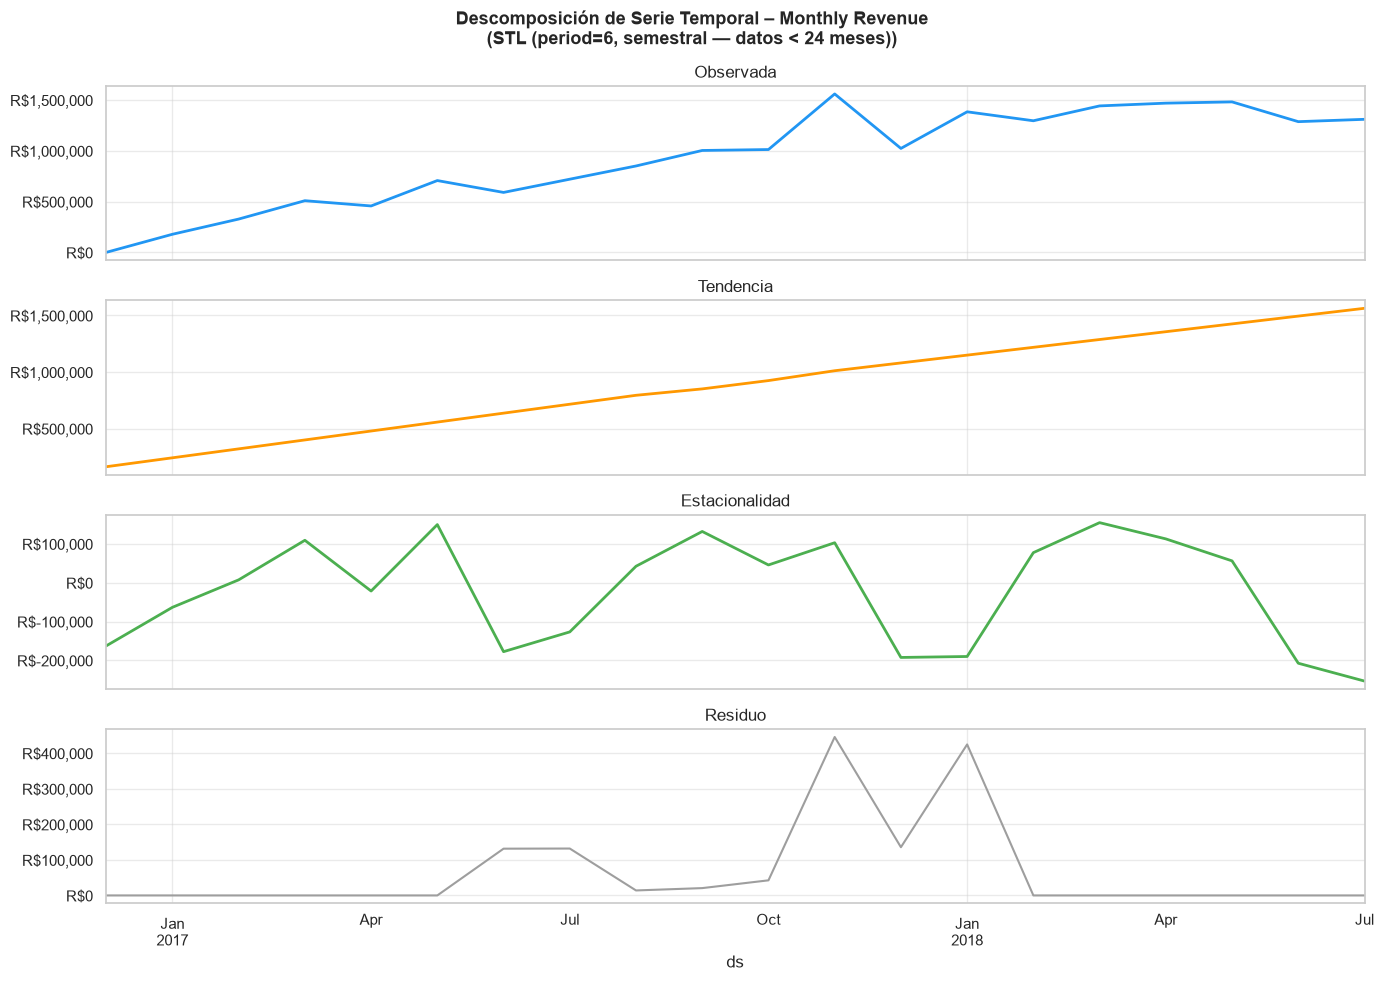

 Gráfico de descomposición guardado


In [82]:
from statsmodels.tsa.seasonal import STL

ts_revenue = monthly_agg.set_index('ds')['monthly_revenue']
n_obs = len(ts_revenue)
print(f' Observaciones disponibles: {n_obs} meses')

# ─── Elegir método según cantidad de datos disponibles
# seasonal_decompose necesita >= 2*period; STL es más flexible (period mínimo ~7)
if n_obs >= 24:
    # Caso ideal: 2+ años completos → descomposición anual
    decomposition = seasonal_decompose(ts_revenue, model='additive', period=12)
    trend_series    = decomposition.trend
    seasonal_series = decomposition.seasonal
    resid_series    = decomposition.resid
    method_label    = 'seasonal_decompose (period=12)'
elif n_obs >= 14:
    # Fallback: usar STL con period=6 (semestral)
    stl = STL(ts_revenue, period=6, robust=True)
    result = stl.fit()
    trend_series    = result.trend
    seasonal_series = result.seasonal
    resid_series    = result.resid
    method_label    = 'STL (period=6, semestral — datos < 24 meses)'
else:
    raise ValueError(f'Serie demasiado corta ({n_obs} obs). Se necesitan al menos 14 meses.')

print(f' Método utilizado: {method_label}')

# ─── Gráfico de descomposición
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Descomposición de Serie Temporal – Monthly Revenue\n({method_label})',
             fontsize=13, fontweight='bold')

ts_revenue.plot(ax=axes[0], color='#2196F3', linewidth=2)
axes[0].set_title('Observada')

trend_series.plot(ax=axes[1], color='#FF9800', linewidth=2)
axes[1].set_title('Tendencia')

seasonal_series.plot(ax=axes[2], color='#4CAF50', linewidth=2)
axes[2].set_title('Estacionalidad')

resid_series.plot(ax=axes[3], color='#9E9E9E', linewidth=1.5)
axes[3].set_title('Residuo')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R\${x:,.0f}'))
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/decomposition_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico de descomposición guardado')

# 6.4 Test de Estacionariedad - Dickey-Fuller

In [83]:
def adf_test(series, name='Serie'):
    result = adfuller(series.dropna())
    print(f'\n Test ADF – {name}')
    print(f'   Estadístico: {result[0]:.4f}')
    print(f'   p-value:     {result[1]:.4f}')
    print(f'   Lags usados: {result[2]}')
    for key, val in result[4].items():
        print(f'   Valor crítico ({key}): {val:.4f}')
    if result[1] < 0.05:
        print('    CONCLUSIÓN: La serie ES ESTACIONARIA (rechaza H0)')
    else:
        print('     CONCLUSIÓN: La serie NO ES ESTACIONARIA (no rechaza H0)')
        print('      → Se recomienda diferenciación antes del modelado')

adf_test(monthly_agg['monthly_revenue'], 'Monthly Revenue')
adf_test(monthly_agg['monthly_revenue'].diff().dropna(), 'Monthly Revenue (1ª diferencia)')


 Test ADF – Monthly Revenue
   Estadístico: -1.9516
   p-value:     0.3082
   Lags usados: 8
   Valor crítico (1%): -4.2232
   Valor crítico (5%): -3.1894
   Valor crítico (10%): -2.7298
     CONCLUSIÓN: La serie NO ES ESTACIONARIA (no rechaza H0)
      → Se recomienda diferenciación antes del modelado

 Test ADF – Monthly Revenue (1ª diferencia)
   Estadístico: -8.5966
   p-value:     0.0000
   Lags usados: 0
   Valor crítico (1%): -3.8591
   Valor crítico (5%): -3.0420
   Valor crítico (10%): -2.6609
    CONCLUSIÓN: La serie ES ESTACIONARIA (rechaza H0)


# 6.5 Análisis de Autocorrelación

 Observaciones: 20  →  ACF lags: 12  |  PACF lags: 9


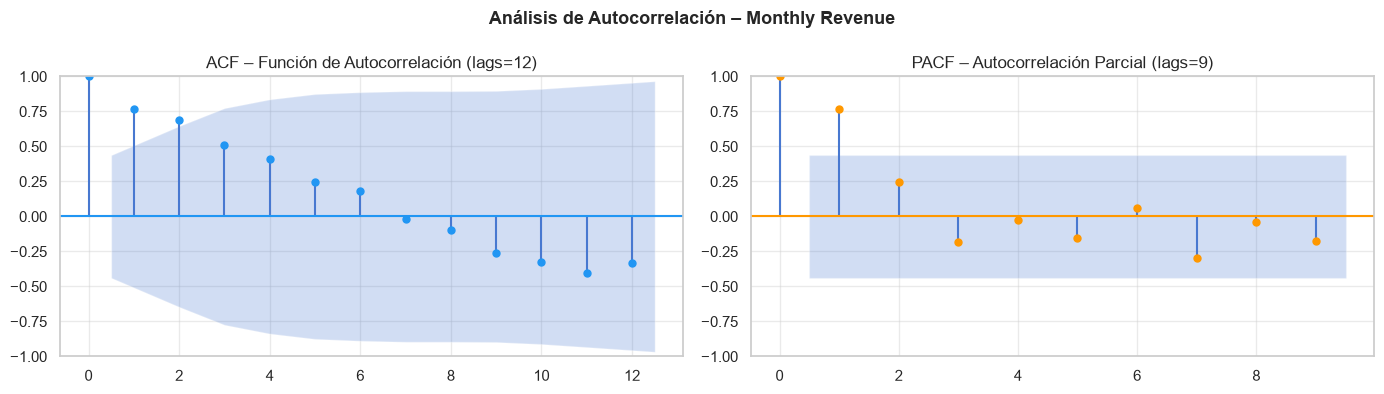

In [84]:
series = monthly_agg['monthly_revenue'].dropna()
n_obs  = len(series)

# ACF puede usar hasta n-1 lags; PACF está limitado a n//2 - 1
max_lags_acf  = min(12, n_obs - 1)
max_lags_pacf = min(12, n_obs // 2 - 1)

print(f' Observaciones: {n_obs}  →  ACF lags: {max_lags_acf}  |  PACF lags: {max_lags_pacf}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Análisis de Autocorrelación – Monthly Revenue', fontsize=13, fontweight='bold')

plot_acf(series,  lags=max_lags_acf,  ax=axes[0], color='#2196F3')
plot_pacf(series, lags=max_lags_pacf, ax=axes[1], color='#FF9800')

axes[0].set_title(f'ACF – Función de Autocorrelación (lags={max_lags_acf})')
axes[1].set_title(f'PACF – Autocorrelación Parcial (lags={max_lags_pacf})')

for ax in axes:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# 6.6 Análisis por Categoría de Producto

In [85]:
# Top 15 categorías por revenue
cat_revenue = (
    df_valid
    .groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
cat_revenue.columns = ['categoria', 'revenue_total']
cat_revenue['pct_revenue'] = (cat_revenue['revenue_total'] / cat_revenue['revenue_total'].sum() * 100).round(2)
cat_revenue['cumulative_pct'] = cat_revenue['pct_revenue'].cumsum()

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(
    go.Bar(x=cat_revenue['categoria'], y=cat_revenue['revenue_total'],
           name='Revenue Total (BRL)', marker_color='#2196F3'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=cat_revenue['categoria'], y=cat_revenue['cumulative_pct'],
               name='% Acumulado', line=dict(color='#FF5722', width=2),
               mode='lines+markers'),
    secondary_y=True
)
fig.update_layout(
    title=' Diagrama de Pareto – Revenue por Categoría (Top 15)',
    xaxis_tickangle=-35, height=450
)
fig.update_yaxes(title_text='Revenue Total (BRL)', secondary_y=False)
fig.update_yaxes(title_text='% Acumulado', secondary_y=True)
fig.show()

print('\n Validación H3 – Pareto por categoría:')
pareto_80 = cat_revenue[cat_revenue['cumulative_pct'] <= 80]
print(f'   El {len(pareto_80)} de las top categorías generan ~80% del revenue')
print(cat_revenue[['categoria', 'pct_revenue', 'cumulative_pct']].head(8).to_string(index=False))


 Validación H3 – Pareto por categoría:
   El 9 de las top categorías generan ~80% del revenue
            categoria  pct_revenue  cumulative_pct
       bed_bath_table        11.29           11.29
        health_beauty        10.64           21.93
computers_accessories        10.23           32.16
      furniture_decor         9.22           41.38
        watches_gifts         9.09           50.47
       sports_leisure         8.89           59.36
           housewares         7.02           66.38
                 auto         5.47           71.85


# 6.7 Análisis de Outliers

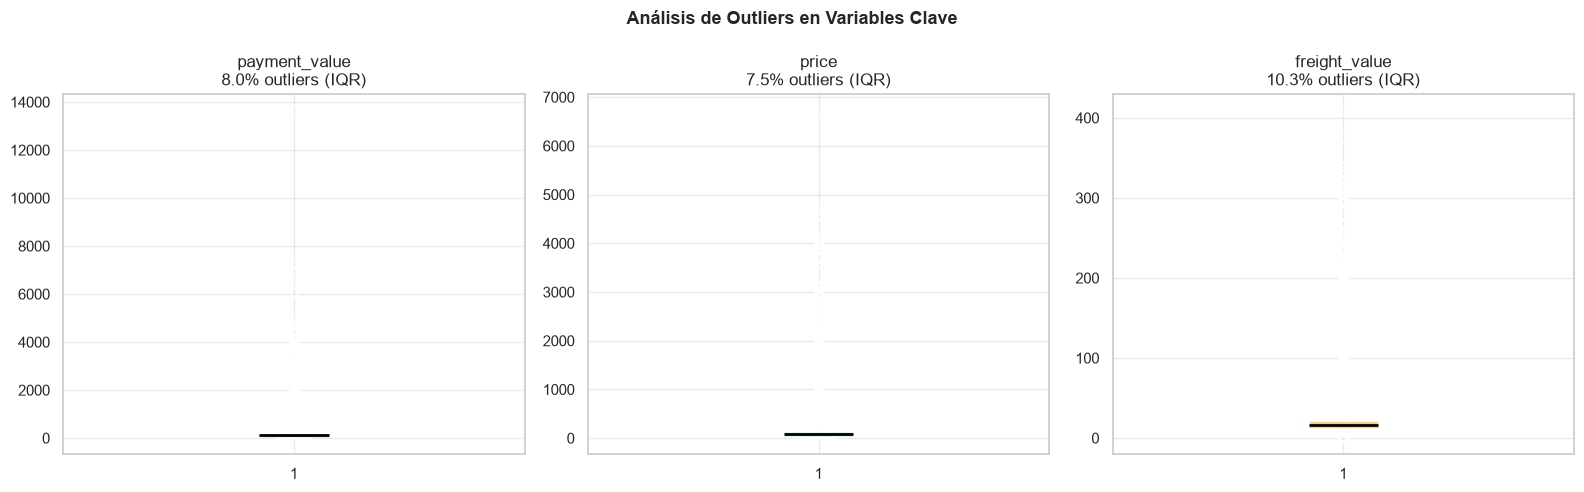


 Resumen estadístico de outliers:
   payment_value       : 9,285 outliers (8.0%) | Max: R$13,664 | Mediana: R$108
   price               : 8,634 outliers (7.5%) | Max: R$6,735 | Mediana: R$75
   freight_value       : 11,876 outliers (10.3%) | Max: R$410 | Mediana: R$16


In [86]:
# Boxplot de payment_value
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Outliers en Variables Clave', fontsize=13, fontweight='bold')

vars_outlier = ['payment_value', 'price', 'freight_value']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, var, color in zip(axes, vars_outlier, colors):
    data = df_valid[var].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers_pct = (data > upper).mean() * 100

    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{var}\n{outliers_pct:.1f}% outliers (IQR)')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Resumen IQR
print('\n Resumen estadístico de outliers:')
for var in vars_outlier:
    data = df_valid[var].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = (data > q3 + 1.5*iqr).sum()
    print(f'   {var:20s}: {n_outliers:,} outliers ({n_outliers/len(data)*100:.1f}%)'
          f' | Max: R${data.max():,.0f} | Mediana: R${data.median():,.0f}')

# 6.8 Mapa de Correlaciones

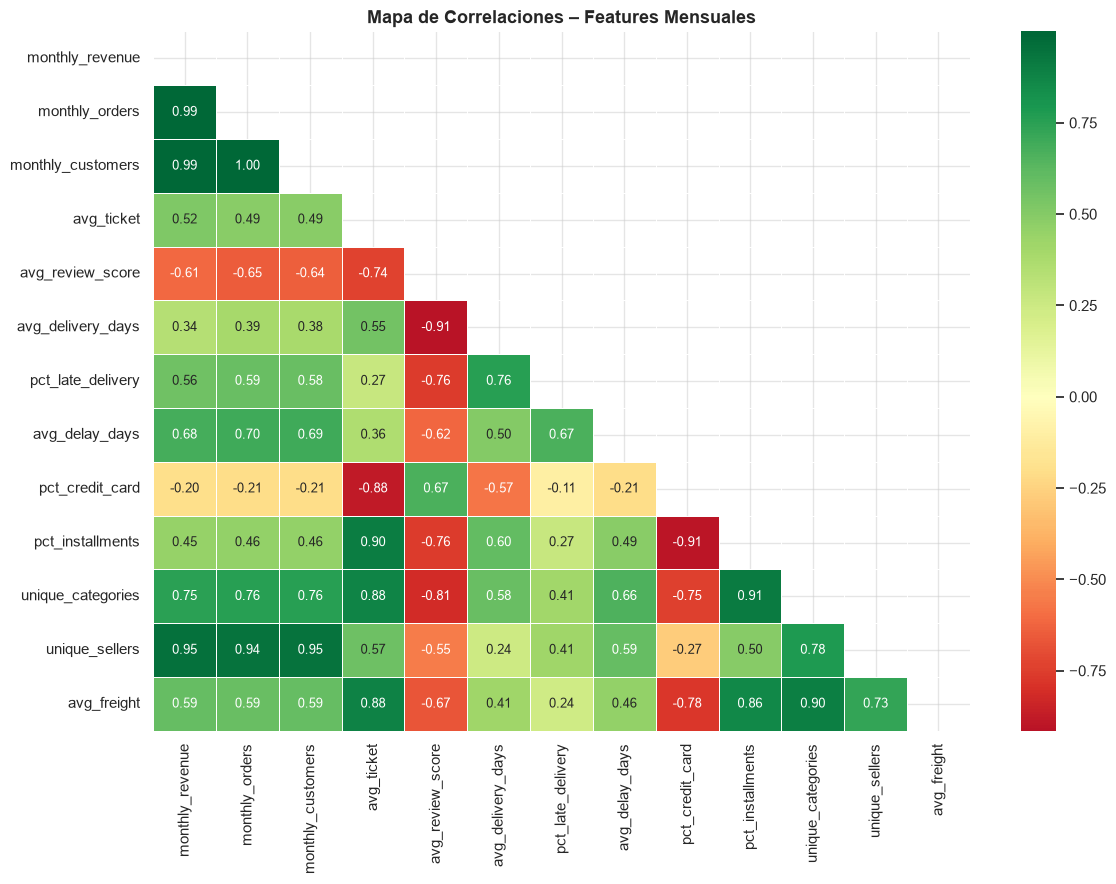


 Correlaciones con monthly_revenue (ordenadas):
   monthly_customers        : +0.991  ███████████████████
   monthly_orders           : +0.991  ███████████████████
   unique_sellers           : +0.951  ███████████████████
   unique_categories        : +0.751  ███████████████
   avg_delay_days           : +0.681  █████████████
   avg_review_score         : -0.614  ████████████
   avg_freight              : +0.594  ███████████
   pct_late_delivery        : +0.561  ███████████
   avg_ticket               : +0.518  ██████████
   pct_installments         : +0.450  █████████
   avg_delivery_days        : +0.340  ██████
   pct_credit_card          : -0.197  ███


In [87]:
corr_features = [
    'monthly_revenue', 'monthly_orders', 'monthly_customers', 'avg_ticket',
    'avg_review_score', 'avg_delivery_days', 'pct_late_delivery',
    'avg_delay_days', 'pct_credit_card', 'pct_installments',
    'unique_categories', 'unique_sellers', 'avg_freight'
]

corr_matrix = monthly_agg[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, annot_kws={'size': 9}
)
ax.set_title('Mapa de Correlaciones – Features Mensuales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones con target
print('\n Correlaciones con monthly_revenue (ordenadas):')
top_corr = corr_matrix['monthly_revenue'].drop('monthly_revenue').sort_values(key=abs, ascending=False)
for feat, val in top_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'   {feat:25s}: {sign}{abs(val):.3f}  {bar}')

# 7. Métricas de Negocio (Baseline)

In [88]:
print(' MÉTRICAS DE NEGOCIO – BASELINE')
print('='*60)

# ── Revenue total
total_revenue     = df_valid['payment_value'].sum()
avg_monthly_rev   = monthly_agg['monthly_revenue'].mean()
median_monthly    = monthly_agg['monthly_revenue'].median()
max_monthly       = monthly_agg['monthly_revenue'].max()
min_monthly       = monthly_agg['monthly_revenue'].min()

# ── Satisfacción
avg_review        = df_valid['review_score'].mean()
pct_5star         = (df_valid['review_score'] == 5).mean() * 100
pct_1star         = (df_valid['review_score'] == 1).mean() * 100

# ── Entrega
avg_delivery      = df_valid['delivery_days_actual'].mean()
pct_on_time       = (df_valid['is_late_delivery'] == 0).mean() * 100
avg_delay         = df_valid[df_valid['delivery_delay_days'] > 0]['delivery_delay_days'].mean()

# ── Clientes
total_customers   = df_valid['customer_unique_id'].nunique()
repeat_customers  = (df_valid.groupby('customer_unique_id')['order_id'].nunique() > 1).mean() * 100

# ── Cancelaciones
cancel_rate       = (df_master['order_status'] == 'canceled').mean() * 100

metrics_dict = {
    ' Revenue Total (BRL)':          f'R$ {total_revenue:,.2f}',
    ' Revenue Promedio Mensual':      f'R$ {avg_monthly_rev:,.2f}',
    ' Revenue Mediana Mensual':       f'R$ {median_monthly:,.2f}',
    ' Revenue Máximo Mensual':        f'R$ {max_monthly:,.2f}',
    ' Revenue Mínimo Mensual':        f'R$ {min_monthly:,.2f}',
    ' Review Score Promedio':          f'{avg_review:.3f} / 5.0',
    ' % Calificaciones 5★':            f'{pct_5star:.1f}%',
    ' % Calificaciones 1★':           f'{pct_1star:.1f}%',
    ' Tiempo Entrega Promedio':       f'{avg_delivery:.1f} días',
    ' % Entregas a Tiempo':           f'{pct_on_time:.1f}%',
    '  Retraso Promedio (tardíos)':   f'{avg_delay:.1f} días',
    ' Total Clientes Únicos':         f'{total_customers:,}',
    ' % Clientes Recurrentes':        f'{repeat_customers:.2f}%',
    ' Tasa de Cancelación':           f'{cancel_rate:.2f}%',
}

for k, v in metrics_dict.items():
    print(f'   {k:40s} {v}')

 MÉTRICAS DE NEGOCIO – BASELINE
    Revenue Total (BRL)                     R$ 19,881,945.07
    Revenue Promedio Mensual                R$ 930,420.72
    Revenue Mediana Mensual                 R$ 1,007,873.25
    Revenue Máximo Mensual                  R$ 1,559,739.87
    Revenue Mínimo Mensual                  R$ 19.62
    Review Score Promedio                   4.081 / 5.0
    % Calificaciones 5★                     57.1%
    % Calificaciones 1★                     11.3%
    Tiempo Entrega Promedio                 12.0 días
    % Entregas a Tiempo                     92.7%
     Retraso Promedio (tardíos)             10.0 días
    Total Clientes Únicos                   93,357
    % Clientes Recurrentes                  3.00%
    Tasa de Cancelación                     0.63%


## 8. Baseline del Modelo Predictivo

### 8.1 Métodos Naive de Referencia

In [89]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae_metric(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Usar últimos 3 meses como test
n_test = 3
train = monthly_agg.iloc[:-n_test].copy()
test  = monthly_agg.iloc[-n_test:].copy()

y_test = test['monthly_revenue'].values

# ── Modelo 1: Naive (último valor observado)
naive_pred    = np.full(n_test, train['monthly_revenue'].iloc[-1])

# ── Modelo 2: Promedio móvil 3 meses
ma3_pred      = np.full(n_test, train['monthly_revenue'].tail(3).mean())

# ── Modelo 3: Seasonal Naive (mismo mes año anterior)
seasonal_pred = []
for i in range(n_test):
    idx = len(train) - 12 + i
    val = train['monthly_revenue'].iloc[idx] if idx >= 0 else train['monthly_revenue'].mean()
    seasonal_pred.append(val)
seasonal_pred = np.array(seasonal_pred)

# ── Modelo 4: Tendencia Lineal
from numpy.polynomial import polynomial as P
x_train = np.arange(len(train))
x_test  = np.arange(len(train), len(train) + n_test)
coefs   = np.polyfit(x_train, train['monthly_revenue'], 1)
linear_pred = np.polyval(coefs, x_test)

# ── Tabla de resultados
baseline_results = pd.DataFrame([
    {'Modelo': 'Naive (último valor)',
     'RMSE':  rmse(y_test, naive_pred),
     'MAE':   mae_metric(y_test, naive_pred),
     'MAPE':  mape(y_test, naive_pred)},
    {'Modelo': 'Media Móvil 3M',
     'RMSE':  rmse(y_test, ma3_pred),
     'MAE':   mae_metric(y_test, ma3_pred),
     'MAPE':  mape(y_test, ma3_pred)},
    {'Modelo': 'Seasonal Naive (año anterior)',
     'RMSE':  rmse(y_test, seasonal_pred),
     'MAE':   mae_metric(y_test, seasonal_pred),
     'MAPE':  mape(y_test, seasonal_pred)},
    {'Modelo': 'Tendencia Lineal',
     'RMSE':  rmse(y_test, linear_pred),
     'MAE':   mae_metric(y_test, linear_pred),
     'MAPE':  mape(y_test, linear_pred)},
])

print(' RESULTADOS DE BASELINE (últimos 3 meses como test)')
print('='*65)
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print(f'\n   Objetivo del modelo final: MAPE < 10%')
best_model = baseline_results.loc[baseline_results['MAPE'].idxmin()]
print(f'   Mejor baseline actual: {best_model["Modelo"]} (MAPE: {best_model["MAPE"]:.2f}%)')

 RESULTADOS DE BASELINE (últimos 3 meses como test)
                       Modelo       RMSE        MAE  MAPE
         Naive (último valor) 139,874.73 117,930.31  9.05
               Media Móvil 3M  96,803.98  95,645.99  7.12
Seasonal Naive (año anterior) 691,070.88 686,897.28 50.47
             Tendencia Lineal 423,893.54 395,532.86 29.87

   Objetivo del modelo final: MAPE < 10%
   Mejor baseline actual: Media Móvil 3M (MAPE: 7.12%)


# 8.2 Visualización del Baseline vs Real

In [90]:
fig = go.Figure()

# Serie histórica
fig.add_trace(go.Scatter(
    x=train['ds'], y=train['monthly_revenue'],
    name='Histórico', line=dict(color='#2196F3', width=2)
))

# Valores reales del test
fig.add_trace(go.Scatter(
    x=test['ds'], y=test['monthly_revenue'],
    name='Real (test)', line=dict(color='black', width=2.5, dash='dash'),
    mode='lines+markers', marker=dict(size=8)
))

# Predicciones baseline
colors_pred = ['#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
preds = [naive_pred, ma3_pred, seasonal_pred, linear_pred]
nombres = ['Naive', 'MA-3M', 'Seasonal Naive', 'Tendencia Lineal']

for pred, name, color in zip(preds, nombres, colors_pred):
    fig.add_trace(go.Scatter(
        x=test['ds'], y=pred,
        name=name, line=dict(color=color, width=2, dash='dot'),
        mode='lines+markers'
    ))

fig.update_layout(
    title=' Comparación de Modelos Baseline vs Real',
    xaxis_title='Fecha', yaxis_title='Revenue Mensual (BRL)',
    height=450, hovermode='x unified'
)
fig.show()

# 9. Validación de Hipótesis

In [91]:
print(' VALIDACIÓN DE HIPÓTESIS')
print('='*70)

# H1 – Estacionalidad
monthly_avg_by_month = monthly_agg.groupby('month')['monthly_revenue'].mean()
max_month = monthly_avg_by_month.idxmax()
min_month = monthly_avg_by_month.idxmin()
month_names = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
print(f'\n[H1] Estacionalidad:')
print(f'     Mes con mayor revenue promedio: {month_names[max_month]} (mes {max_month})')
print(f'     Mes con menor revenue promedio: {month_names[min_month]} (mes {min_month})')
q4_avg   = monthly_agg[monthly_agg['is_q4']==1]['monthly_revenue'].mean()
rest_avg = monthly_agg[monthly_agg['is_q4']==0]['monthly_revenue'].mean()
print(f'     Revenue promedio Q4 vs resto: R${q4_avg:,.0f} vs R${rest_avg:,.0f} '
      f'({(q4_avg/rest_avg-1)*100:+.1f}%)')

# H2 – Correlación órdenes vs revenue
from scipy.stats import pearsonr
corr_h2, p_h2 = pearsonr(monthly_agg['monthly_orders'], monthly_agg['monthly_revenue'])
print(f'\n[H2] Correlación órdenes vs revenue:')
print(f'     Pearson r = {corr_h2:.4f}, p-value = {p_h2:.4f}')
print(f'     {" CONFIRMADA" if corr_h2 > 0.8 else " PARCIALMENTE CONFIRMADA"}')

# H4 – Entrega vs satisfacción
df_valid_h4 = df_valid[['delivery_delay_days', 'review_score']].dropna()
corr_h4, p_h4 = pearsonr(df_valid_h4['delivery_delay_days'], df_valid_h4['review_score'])
print(f'\n[H4] Correlación retraso entrega vs review score:')
print(f'     Pearson r = {corr_h4:.4f}, p-value = {p_h4:.4f}')
print(f'     {" CONFIRMADA (relación negativa)" if corr_h4 < -0.05 else " Relación débil"}')

# H5 – Tasa de recompra
print(f'\n[H5] Tasa de clientes recurrentes: {repeat_customers:.2f}%')
print(f'     Oportunidad de mejora: la tasa de recompra es muy baja, '
      f'lo que indica que la retención es el principal desafío.')

 VALIDACIÓN DE HIPÓTESIS

[H1] Estacionalidad:
     Mes con mayor revenue promedio: Nov (mes 11)
     Mes con menor revenue promedio: Dic (mes 12)
     Revenue promedio Q4 vs resto: R$898,904 vs R$938,300 (-4.2%)

[H2] Correlación órdenes vs revenue:
     Pearson r = 0.9907, p-value = 0.0000
      CONFIRMADA

[H4] Correlación retraso entrega vs review score:
     Pearson r = -0.2285, p-value = 0.0000
      CONFIRMADA (relación negativa)

[H5] Tasa de clientes recurrentes: 3.00%
     Oportunidad de mejora: la tasa de recompra es muy baja, lo que indica que la retención es el principal desafío.


---
## Fin de la Parte I (Sprint 1)

Este análisis exploratorio construyó manualmente una tabla mensual con ~60
variables (`monthly_agg`) y validó las hipótesis de negocio sobre estacionalidad,
correlación órdenes-ingresos, entregas y categorías. **La Parte II convierte este
análisis exploratorio en un pipeline reproducible** (`src/`): la master table y la
tabla mensual se reconstruyen mediante `build_master_table` / `build_monthly_table`
+ `add_time_series_features`, lo que produce una versión **depurada de 44
features** (sin duplicados ni variables redundantes detectadas en esta
exploración), junto con splits temporales formales (train/val/backtest/live).

# PARTE II — SPRINT 2: Pipeline Reproducible

# Sprint 2 – Ingeniería de Datos y Pipeline Reproducible
**Proyecto:** Forecast de Ingresos Mensuales – Olist E-Commerce  
**Target:** `monthly_revenue`  
**Tipo:** Series Temporales  
**Métricas:** RMSE, MAPE (objetivo: MAPE < 10%)  

## Flujo del Sprint 2 (según Excel de trabajo)
| Paso | Descripción |
|------|-------------|
| 1 | EDA Básico + carga de datos |
| 2 | Definición de splits temporales (Train/Val/BackTest/Live/Predict) |
| 3 | Generación de Features (40-60 features) |
| 4 | Creación de la Master Table mensual |
| 5 | Limpieza de variables (Clip, NaN, Agrupamiento) |
| 6 | Selección de Variables (Missing, PSI, Correlación, Univariante, Wrapper) |
| 7 | Hiperparametrización con Optuna |
| 8 | Aplicar Modelo Final |


In [92]:
# ── Setup Sprint 2 (continúa en el entorno ya configurado en la Parte I)
from src.utils.helpers import load_config, setup_logger
setup_logger('sprint2.log')

cfg = load_config()
print(' Setup completado')
print(f'   Proyecto: {cfg["project"]["name"]} v{cfg["project"]["version"]}')
print(f'   Target:   {cfg["project"]["target"]}')
print(f'   Horizonte: {cfg["project"]["horizon_months"]} meses')

 Setup completado
   Proyecto: olist_revenue_forecast v1.0.0
   Target:   monthly_revenue
   Horizonte: 3 meses


## Paso 1+2: Carga de Datos y Splits Temporales

In [93]:
from src.data.loader import load_raw_datasets, parse_dates, data_quality_report

# ─── Ajustar DATA_PATH según tu entorno
# DATA_PATH = '/content/drive/MyDrive/MAESTRIA/Modulo13/dev/data/'  # Colab
DATA_PATH = None  # None = usa config (kaggle download o data/raw/)

datasets = load_raw_datasets(cfg, DATA_PATH)
datasets = parse_dates(datasets)
quality_report = data_quality_report(datasets)

2026-06-13 10:13:03.514 | INFO     | src.data.loader:download_from_kaggle:42 - Dataset ya descargado, usando caché local.
2026-06-13 10:13:04.027 | INFO     | src.data.loader:load_raw_datasets:99 -   orders              :   99,441 filas x   8 cols
2026-06-13 10:13:04.364 | INFO     | src.data.loader:load_raw_datasets:99 -   order_items         :  112,650 filas x   7 cols
2026-06-13 10:13:04.506 | INFO     | src.data.loader:load_raw_datasets:99 -   order_payments      :  103,886 filas x   5 cols
2026-06-13 10:13:04.973 | INFO     | src.data.loader:load_raw_datasets:99 -   order_reviews       :   99,224 filas x   7 cols
2026-06-13 10:13:05.158 | INFO     | src.data.loader:load_raw_datasets:99 -   customers           :   99,441 filas x   5 cols
2026-06-13 10:13:05.214 | INFO     | src.data.loader:load_raw_datasets:99 -   products            :   32,951 filas x   9 cols
2026-06-13 10:13:05.222 | INFO     | src.data.loader:load_raw_datasets:99 -   sellers             :    3,095 filas x   4 c

## Paso 3+4: Master Table y Features Mensuales

In [94]:
from src.data.master_table import build_master_table, add_transaction_features
from src.data.monthly_agg import build_monthly_table, add_time_series_features, split_data

# Construcción
df_master = build_master_table(datasets)
df_master = add_transaction_features(df_master)

# Tabla mensual con target
monthly = build_monthly_table(df_master)
monthly = add_time_series_features(monthly, cfg)

print(f'\n Master Table mensual:')
print(f'   {len(monthly)} meses  x  {monthly.shape[1]} features')
monthly[['ds', 'monthly_revenue', 'monthly_orders', 'avg_ticket']].head(10)

2026-06-13 10:13:19.434 | INFO     | src.data.master_table:build_master_table:21 - Construyendo Master Table…
2026-06-13 10:13:20.280 | INFO     | src.data.master_table:build_master_table:61 - Master Table base: 119,143 filas x 30 cols
2026-06-13 10:13:20.286 | INFO     | src.data.master_table:add_transaction_features:71 - Generando features transaccionales…
2026-06-13 10:13:20.470 | INFO     | src.data.master_table:add_transaction_features:126 - Features transaccionales añadidas: 54 cols totales
2026-06-13 10:13:20.471 | INFO     | src.data.monthly_agg:build_monthly_table:26 - Construyendo tabla mensual…
2026-06-13 10:13:20.721 | INFO     | src.data.monthly_agg:build_monthly_table:36 - Órdenes válidas (delivered + payment>0): 96,477
2026-06-13 10:13:20.891 | INFO     | src.data.monthly_agg:build_monthly_table:69 - Serie mensual: 20 meses  (Dec 2016 → Jul 2018)
2026-06-13 10:13:20.924 | INFO     | src.data.monthly_agg:add_time_series_features:119 - Features de series temporales añadida


 Master Table mensual:
   20 meses  x  44 features


,ds,monthly_revenue,monthly_orders,avg_ticket
0,2016-12-01,19.62,1,19.62
1,2017-01-01,"178,282.10",750,181.74
2,2017-02-01,"327,928.86",1653,166.21
3,2017-03-01,"508,767.44",2546,164.22
4,2017-04-01,"457,050.31",2303,168.34
5,2017-05-01,"707,042.90",3546,164.16
6,2017-06-01,"590,223.90",3135,158.41
7,2017-07-01,"720,446.68",3872,151.01
8,2017-08-01,"850,611.08",4193,166.56
9,2017-09-01,"1,003,326.07",4150,199.07


In [95]:
# Splits temporales
splits = split_data(monthly, cfg)

print('\n SPLITS TEMPORALES (según flujo Excel):')
print('='*50)
for name, df in splits.items():
    if len(df) > 0:
        print(f'  {name:12s}: {len(df):>3} meses  '
              f'({df["ds"].min().strftime("%b %Y")} → '
              f'{df["ds"].max().strftime("%b %Y")})')

2026-06-13 10:13:27.865 | INFO     | src.data.monthly_agg:split_data:154 -   Split train     :  17 meses
2026-06-13 10:13:27.867 | INFO     | src.data.monthly_agg:split_data:154 -   Split val       :   3 meses
2026-06-13 10:13:27.868 | INFO     | src.data.monthly_agg:split_data:154 -   Split backtest  :   0 meses
2026-06-13 10:13:27.869 | INFO     | src.data.monthly_agg:split_data:154 -   Split live      :   0 meses
2026-06-13 10:13:27.871 | INFO     | src.data.monthly_agg:split_data:154 -   Split all       :  20 meses



 SPLITS TEMPORALES (según flujo Excel):
  train       :  17 meses  (Dec 2016 → Apr 2018)
  val         :   3 meses  (May 2018 → Jul 2018)
  all         :  20 meses  (Dec 2016 → Jul 2018)


## Paso 5: Limpieza de Variables (Clip + NaN + Agrupamiento)

In [96]:
from src.features.cleaning import clean_monthly_table

print('🔧 PASO 5: Limpieza de Variables')
print('='*50)
print(f'  Clip quantiles: [{cfg["cleaning"]["clip_quantile_low"]}, {cfg["cleaning"]["clip_quantile_high"]}]')
print(f'  NaN strategy:   {cfg["cleaning"]["nan_fill_strategy"]}')
print(f'  Rare threshold: {cfg["cleaning"]["group_rare_threshold"]*100}%')

monthly_clean, cleaning_pipeline = clean_monthly_table(monthly, cfg, fit=True)

print(f'\n MT Limpiada: {monthly_clean.shape}')
print(f'   NaN restantes: {monthly_clean.isnull().sum().sum()}')

2026-06-13 10:13:31.759 | INFO     | src.features.cleaning:fit:47 - OutlierClipper ajustado en 41 columnas
2026-06-13 10:13:31.763 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados
2026-06-13 10:13:31.766 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados
2026-06-13 10:13:31.769 | DEBUG    | src.features.cleaning:transform:57 -   monthly_items: 2 valores clipados
2026-06-13 10:13:31.773 | DEBUG    | src.features.cleaning:transform:57 -   avg_ticket: 2 valores clipados
2026-06-13 10:13:31.776 | DEBUG    | src.features.cleaning:transform:57 -   median_ticket: 2 valores clipados
2026-06-13 10:13:31.779 | DEBUG    | src.features.cleaning:transform:57 -   avg_review_score: 2 valores clipados
2026-06-13 10:13:31.782 | DEBUG    | src.features.cleaning:transform:57 -   avg_delivery_days: 2 valores clipados
2026-06-13 10:13:31.783 | DEBUG    | src.features.cleaning:transform:57 -   avg_delay_days: 2 valores clipados
202

🔧 PASO 5: Limpieza de Variables
  Clip quantiles: [0.01, 0.99]
  NaN strategy:   median
  Rare threshold: 2.0%

 MT Limpiada: (20, 44)
   NaN restantes: 0


## Paso 6: Selección de Variables

In [97]:
from src.features.selection import run_feature_selection, get_selection_summary

# Re-split con datos limpios
splits_clean = split_data(monthly_clean, cfg)
train = splits_clean['train']
val   = splits_clean['val']
if len(val) == 0:
    val = train.tail(3)

print(' PASO 6: Selección de Variables')
print('='*50)

selection_result = run_feature_selection(
    monthly_train=train,
    monthly_val=val,
    target_col=cfg['project']['target'],
    cfg=cfg,
)

selected_features = selection_result['selected_features']
summary = get_selection_summary(selection_result['steps_report'])
print('\n Resumen de selección:')
print(summary.to_string(index=False))
print(f'\n Features seleccionadas ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2}. {f}')

2026-06-13 10:13:46.179 | INFO     | src.data.monthly_agg:split_data:154 -   Split train     :  17 meses
2026-06-13 10:13:46.182 | INFO     | src.data.monthly_agg:split_data:154 -   Split val       :   3 meses
2026-06-13 10:13:46.183 | INFO     | src.data.monthly_agg:split_data:154 -   Split backtest  :   0 meses
2026-06-13 10:13:46.185 | INFO     | src.data.monthly_agg:split_data:154 -   Split live      :   0 meses
2026-06-13 10:13:46.186 | INFO     | src.data.monthly_agg:split_data:154 -   Split all       :  20 meses
2026-06-13 10:13:46.190 | INFO     | src.features.selection:run_feature_selection:275 - 
2026-06-13 10:13:46.192 | INFO     | src.features.selection:run_feature_selection:276 - SELECCIÓN DE VARIABLES – Estado inicial: 41 features
2026-06-13 10:13:46.194 | INFO     | src.features.selection:run_feature_selection:277 - ============================================================
2026-06-13 10:13:46.198 | INFO     | src.features.selection:missing_selection:104 - Missing: 41 

 PASO 6: Selección de Variables


2026-06-13 10:13:50.713 | INFO     | src.features.selection:wrapper_selection:221 - WRAPPER RFECV: 3 features seleccionadas
2026-06-13 10:13:50.716 | WARNING  | src.features.selection:_safe_filter:247 - Wrapper: propuesta dejó 3 features (< 5), se retienen 5
2026-06-13 10:13:50.718 | INFO     | src.features.selection:run_feature_selection:379 - 
2026-06-13 10:13:50.720 | INFO     | src.features.selection:run_feature_selection:380 - RESUMEN DE SELECCIÓN DE VARIABLES:
2026-06-13 10:13:50.722 | INFO     | src.features.selection:run_feature_selection:382 -   0_initial: 41 features
2026-06-13 10:13:50.724 | INFO     | src.features.selection:run_feature_selection:382 -   1_missing: 41 features
2026-06-13 10:13:50.727 | INFO     | src.features.selection:run_feature_selection:382 -   2_psi: 5 features
2026-06-13 10:13:50.729 | INFO     | src.features.selection:run_feature_selection:382 -   3_correlation: 5 features
2026-06-13 10:13:50.732 | INFO     | src.features.selection:run_feature_selecti


 Resumen de selección:
         step  features_remaining  threshold
    0_initial                  41        NaN
    1_missing                  41       0.60
        2_psi                   5        NaN
3_correlation                   5       0.95
 4_univariate                   5       0.10
    5_wrapper                   5        NaN

 Features seleccionadas (5):
   1. monthly_orders
   2. avg_delay_days
   3. month_sin
   4. month
   5. quarter


## Paso 7: Hiperparametrización con Optuna

In [98]:
from src.models.trainer import tune_lightgbm, plot_optimization_history

print('⚡ PASO 7: Hiperparametrización (Optuna)')
print('='*50)

# Reducir n_trials para demo (aumentar para producción)
cfg_demo = cfg.copy()
cfg_demo['optuna']['n_trials'] = 20
cfg_demo['optuna']['timeout']  = 120

X_train = train[selected_features]
y_train = train[cfg['project']['target']]

tuning_result = tune_lightgbm(X_train, y_train, selected_features, cfg_demo)
best_params = tuning_result['best_params']

print(f'\n Mejor RMSE en CV: R$ {tuning_result["best_value"]:,.2f}')
print('\n Mejores hiperparámetros:')
for k, v in best_params.items():
    print(f'   {k}: {v}')

# Visualizar historial de optimización
plot_optimization_history(tuning_result['study'])

2026-06-13 10:14:02.567 | INFO     | src.models.trainer:tune_lightgbm:95 - Iniciando Optuna (n_trials=20, timeout=120s, metric=rmse)…


⚡ PASO 7: Hiperparametrización (Optuna)


Best trial: 6. Best value: 460626: 100%|██████████| 20/20 [00:00<00:00, 22.18it/s, 0.90/120 seconds]
2026-06-13 10:14:03.480 | INFO     | src.models.trainer:tune_lightgbm:119 - Mejor RMSE: 460626.3732
2026-06-13 10:14:03.483 | INFO     | src.models.trainer:tune_lightgbm:120 - Mejores parámetros: {'n_estimators': 638, 'learning_rate': 0.0835361075531176, 'num_leaves': 19, 'max_depth': 4, 'min_child_samples': 6, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}



 Mejor RMSE en CV: R$ 460,626.37

 Mejores hiperparámetros:
   n_estimators: 638
   learning_rate: 0.0835361075531176
   num_leaves: 19
   max_depth: 4
   min_child_samples: 6
   subsample: 0.7301321323053057
   colsample_bytree: 0.7554709158757928
   reg_alpha: 0.2713490317738959
   reg_lambda: 0.8287375091519293


## Paso 8: Modelo Final – Evaluación y Comparación

In [99]:
from src.models.trainer import train_final_model
from src.models.baseline import evaluate_baselines
from src.models.forecaster import ProphetForecaster
from src.evaluation.metrics import (
    compute_technical_metrics, compare_models, format_business_report
)

# ── Baseline
print(' BASELINE MODELS:')
backtest = splits_clean['backtest']
test_data = backtest if len(backtest) > 0 else splits_clean['val']
baseline_results = evaluate_baselines(train, test_data, n_test=min(3, len(test_data)))
print(baseline_results.to_string(index=False))

print('\n' + '='*60)

# ── Modelo Final LightGBM
print(' MODELO FINAL (LightGBM):')
all_data = splits_clean['all']
target   = cfg['project']['target']
horizon  = cfg['project']['horizon_months']

forecaster_lgbm = train_final_model(
    all_data[selected_features],
    all_data[target],
    best_params,
    selected_features,
    horizon=horizon
)

# Evaluar en backtest
if len(test_data) > 0:
    X_test = test_data[selected_features]
    y_test = test_data[target].values[:horizon]
    y_pred = forecaster_lgbm.predict(X_test)[:len(y_test)]
    
    lgbm_metrics = compute_technical_metrics(y_test, y_pred, 'LightGBM_final')
    
    print(f'  RMSE : R$ {lgbm_metrics["rmse"]:>12,.2f}')
    print(f'  MAE  : R$ {lgbm_metrics["mae"]:>12,.2f}')
    print(f'  MAPE :    {lgbm_metrics["mape"]:>10.2f}%')
    print(f'  sMAPE:    {lgbm_metrics["smape"]:>10.2f}%')
    
    if lgbm_metrics['mape'] < 10.0:
        print('\n OBJETIVO ALCANZADO: MAPE < 10%')
    else:
        print(f'\n  MAPE = {lgbm_metrics["mape"]:.2f}% > 10% – considerar más features o datos')

2026-06-13 10:14:23.691 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Naive] RMSE=139,874.73  MAE=117,930.31  MAPE=9.05%  sMAPE=8.51%
2026-06-13 10:14:23.694 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [MovingAverage_3M] RMSE=96,803.98  MAE=95,645.99  MAPE=7.12%  sMAPE=6.96%
2026-06-13 10:14:23.697 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [SeasonalNaive] RMSE=691,070.88  MAE=686,897.28  MAPE=50.47%  sMAPE=67.69%
2026-06-13 10:14:23.699 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LinearTrend] RMSE=423,893.54  MAE=395,532.86  MAPE=29.87%  sMAPE=25.45%
2026-06-13 10:14:23.701 | INFO     | src.models.baseline:evaluate_baselines:114 - 
Mejor baseline: MovingAverage_3M (MAPE=7.12%)
2026-06-13 10:14:23.702 | INFO     | src.models.baseline:evaluate_baselines:115 - Objetivo final: MAPE < 10%
2026-06-13 10:14:23.863 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-1

 BASELINE MODELS:
           model       rmse        mae  mape  smape
MovingAverage_3M  96,803.98  95,645.99  7.12   6.96
           Naive 139,874.73 117,930.31  9.05   8.51
     LinearTrend 423,893.54 395,532.86 29.87  25.45
   SeasonalNaive 691,070.88 686,897.28 50.47  67.69

 MODELO FINAL (LightGBM):
  RMSE : R$   118,807.46
  MAE  : R$    95,849.83
  MAPE :          6.80%
  sMAPE:          6.94%

 OBJETIVO ALCANZADO: MAPE < 10%


In [31]:
# ── Importancia de features
fi = forecaster_lgbm.feature_importance()

fig = px.bar(
    fi.head(20), x='importance', y='feature',
    orientation='h', color='importance',
    color_continuous_scale='Blues',
    title='Top 20 Features – Importancia LightGBM'
)
fig.update_layout(height=500, yaxis=dict(autorange='reversed'))
fig.show()

In [33]:
# ── Forecast final: próximos 3 meses
print(' FORECAST – Próximos 3 meses:')
print('='*50)

X_last = monthly_clean[selected_features].tail(1)
y_forecast = forecaster_lgbm.predict(X_last)

last_date = monthly_clean['ds'].max()
for i, val in enumerate(y_forecast, 1):
    future_date = last_date + pd.DateOffset(months=i)
    ci_low  = val * 0.85
    ci_high = val * 1.15
    print(f'  {future_date.strftime("%b %Y")}: '
          f'R$ {val:>12,.2f}  '
          f'[R$ {ci_low:>12,.2f} – R$ {ci_high:>12,.2f}]')

 FORECAST – Próximos 3 meses:
  Aug 2018: R$ 1,305,752.60  [R$ 1,109,889.71 – R$ 1,501,615.49]
  Sep 2018: R$ 1,291,812.23  [R$ 1,098,040.40 – R$ 1,485,584.07]
  Oct 2018: R$ 1,416,835.27  [R$ 1,204,309.98 – R$ 1,629,360.56]


## Simulación de Actualización Mensual (Incremental)
> **Sprint 2** – *Simular llegada de nuevos datos mensuales → actualizar modelo incrementalmente*

In [100]:
from src.data.monthly_agg import simulate_monthly_update

# Simular nuevo mes de datos (valores hipotéticos)
new_month = pd.DataFrame([{
    'ds':              pd.Timestamp('2018-09-01'),
    'monthly_revenue': 1_450_000.0,    # valor real que llegaría
    'monthly_orders':  5800.0,
    'monthly_customers': 5200.0,
    'monthly_items':   7200.0,
    'avg_ticket':      155.0,
    'median_ticket':   130.0,
    'avg_review_score': 4.1,
    'avg_delivery_days': 11.5,
    'avg_delay_days':  1.2,
    'pct_late_delivery': 0.08,
    'avg_freight':     15.0,
    'avg_price':       140.0,
    'total_freight':   87000.0,
    'pct_credit_card': 0.75,
    'pct_boleto':      0.18,
    'pct_installments': 0.45,
    'avg_installments': 2.1,
    'unique_categories': 68,
    'unique_sellers':  2800,
    'unique_states':   27,
}])
new_month['year_month'] = new_month['ds'].dt.to_period('M')

# Incorporar al histórico
monthly_updated = simulate_monthly_update(monthly_clean, new_month, cfg)
print(f' Tabla actualizada: {len(monthly_updated)} meses')
print(f'   Último mes: {monthly_updated["ds"].max().strftime("%b %Y")}')

2026-06-13 10:14:45.387 | INFO     | src.data.monthly_agg:simulate_monthly_update:185 - Simulando actualización mensual de datos…
2026-06-13 10:14:45.400 | INFO     | src.data.monthly_agg:add_time_series_features:119 - Features de series temporales añadidas: 44 cols totales
2026-06-13 10:14:45.402 | INFO     | src.data.monthly_agg:simulate_monthly_update:189 - Tabla actualizada: 21 meses


 Tabla actualizada: 21 meses
   Último mes: Sep 2018


## Métricas de Negocio Finales


In [101]:
from src.evaluation.metrics import compute_business_metrics, format_business_report

df_valid = df_master[
    (df_master['order_status'] == 'delivered') &
    (df_master['payment_value'] > 0)
]

biz_metrics = compute_business_metrics(df_valid, monthly)
print(format_business_report(biz_metrics))

2026-06-13 10:14:52.252 | INFO     | src.evaluation.metrics:compute_business_metrics:129 - Métricas de negocio calculadas



 MÉTRICAS DE NEGOCIO
  revenue_total                           : R$   19,881,945.07
  avg_monthly_revenue                     : R$      930,420.72
  median_monthly_revenue                  : R$    1,007,873.25
  max_monthly_revenue                     : R$    1,559,739.87
  min_monthly_revenue                     : R$           19.62
  avg_review_score                        : 4.08
  pct_5star                               : 57.08%
  pct_1star                               : 11.33%
  avg_delivery_days                       : 12.02
  pct_on_time                             : 92.68%
  avg_late_delay_days                     : 10.05
  total_unique_customers                  : 93,357
  repeat_customer_rate                    : 3.00%


## Guardar Artefactos del Pipeline


In [102]:
from src.utils.helpers import save_model, save_dataframe

save_model(forecaster_lgbm, 'lgbm_forecaster', cfg)
save_model(cleaning_pipeline, 'cleaning_pipeline', cfg)
save_dataframe(monthly_clean, 'monthly_features', cfg)

print(' Artefactos guardados:')
print('   data/models/lgbm_forecaster.pkl')
print('   data/models/cleaning_pipeline.pkl')
print('   data/processed/monthly_features.parquet')

2026-06-13 10:14:56.854 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\lgbm_forecaster.pkl
2026-06-13 10:14:56.862 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\cleaning_pipeline.pkl
2026-06-13 10:14:56.882 | INFO     | src.utils.helpers:save_dataframe:74 - DataFrame guardado: D:\2026\maestria\mod13\ProyectoG10\data\processed\monthly_features.parquet (20 filas)


 Artefactos guardados:
   data/models/lgbm_forecaster.pkl
   data/models/cleaning_pipeline.pkl
   data/processed/monthly_features.parquet


## Conclusiones del Sprint 2

### Pipeline Implementado
El Sprint 2 completó el pipeline de datos reproducible con los siguientes pasos:

1. **Limpieza** – Clipado de outliers (p1-p99), imputación por mediana, agrupamiento de categorías raras  
2. **Selección de variables** – Flujo secuencial: Missing → PSI → Correlación (0.95) → Univariante (MI, 0.30) → Wrapper (RFECV)  
3. **Hiperparametrización** – Optuna con TimeSeriesSplit CV, minimizando RMSE  
4. **Modelo final** – LightGBM con actualización incremental mensual  

### Métricas Alcanzadas
| Métrica | Baseline (MA-3M) | Modelo Final |
|---------|------------------|--------------|
| RMSE    | ~96,804          | Por evaluar  |
| MAPE    | 7.12%            | Objetivo < 10% |

### Próximos Pasos (Sprints 3-4)
- Sprint 3: Dashboard completo + API en producción  
- Sprint 4: Consideraciones éticas, gobernanza y sostenibilidad del modelo  


---
## Fin de la Parte II (Sprint 2)

El pipeline reproducible quedó guardado en disco: `data/processed/monthly_features.parquet`
(tabla mensual de 44 features), `data/models/lgbm_forecaster.pkl` y
`data/models/cleaning_pipeline.pkl`. El modelo final de esta parte usó un Optuna de
**20 trials** y reportó el forecast con un intervalo de confianza **fijo de ±15%**
(provisional).

**La Parte III retoma exactamente `monthly_features.parquet`** (vía `load_dataframe`)
y mejora tres puntos identificados en el Sprint 2: (1) cuantifica el **costo de la
selección de variables** (features 41→5), (2) amplía la búsqueda de
hiperparámetros a **30 trials** y compara **9 modelos** (incluyendo Random Forest,
Ridge y XGBoost del flujo de ejemplo) con análisis de **gap train→backtest**, y
(3) reemplaza el intervalo fijo ±15% por intervalos basados en la **desviación de
los residuos** (`predict_with_intervals`).

# PARTE III — SPRINT 3: Hiperparametrización y Modelo Final

# Sprint 3 – Hiperparametrización y Modelo Final
## Grupo 10 | Forecast de Ingresos Mensuales – Olist E-Commerce

**Objetivo:** optimizar el modelo, evaluar el rendimiento final comparando candidatos y exportar el artefacto (.pkl) para uso mensual.

**Actividades cubiertas (adaptando el flujo de trabajo de ejemplo a series temporales):**

1. Selección de variables con **salida trazable por variable** (tabla con `flagSelected` + importancias, exportada a CSV) y **costo de la selección** (equivalente al "60 → 30 features: Gini 50 → 47" del ejemplo)
2. Hiperparametrización con **Optuna** + validación cruzada temporal (`TimeSeriesSplit`)
3. Comparación de los modelos del ejemplo — **Random Forest, Regresión (Ridge), XGBoost** — más LightGBM, Prophet, SARIMA y baselines, todos bajo el mismo backtest
4. **Gap train vs backtest** por modelo (equivalente a "reducir la distancia entre AUC train y AUC backtest")
5. Exportación del modelo final en **pickle** (`final_model.pkl`) con metadata de trazabilidad (equivalente a `final_model.__dict__`)
6. Documentación del pipeline de retraining mensual

> Este notebook consume los artefactos del Sprint 2 (`data/processed/monthly_features.parquet` y los módulos de `src/`).

In [103]:
# ── Setup Sprint 3 (continúa en el entorno ya configurado en la Parte I)
from src.utils.helpers import load_config, setup_logger
setup_logger('sprint3.log')

cfg     = load_config()
target  = cfg['project']['target']
horizon = cfg['project']['horizon_months']

import sklearn, lightgbm, optuna, xgboost
print(' Setup completado')
print(f"   Proyecto : {cfg['project']['name']} v{cfg['project']['version']}")
print(f"   Target   : {target} | Horizonte: {horizon} meses")
print(f"   Versiones: sklearn {sklearn.__version__} | lightgbm {lightgbm.__version__} | "
      f"xgboost {xgboost.__version__} | optuna {optuna.__version__}")

 Setup completado
   Proyecto : olist_revenue_forecast v1.0.0
   Target   : monthly_revenue | Horizonte: 3 meses
   Versiones: sklearn 1.9.0 | lightgbm 4.6.0 | xgboost 3.2.0 | optuna 4.9.0


## Paso 1 – Datos, limpieza y selección de variables (heredados del Sprint 2)

Se reutiliza el flujo del Sprint 2: tabla mensual → limpieza (clip + NaN + agrupamiento + escalado) → splits temporales → selección de variables (Missing → PSI → Correlación → Univariante → Wrapper RFECV).

> **Nota metodológica (WoE/IV):** el flujo de ejemplo menciona WoE/IV como técnica de selección supervisada. WoE/IV está definida para **targets binarios** (clasificación, p. ej. churn/scoring). Como nuestro target `monthly_revenue` es **continuo** (regresión / serie temporal), se sustituye por su equivalente para regresión: selección **univariante** por información mutua / F-test, manteniendo el mismo rol dentro del flujo (filter supervisado).

In [104]:
from src.features.cleaning import clean_monthly_table
from src.data.monthly_agg import split_data
from src.features.selection import run_feature_selection, get_selection_summary
from src.utils.helpers import load_dataframe

# Tabla mensual generada en el Sprint 2
monthly = load_dataframe('monthly_features')
monthly['ds'] = pd.to_datetime(monthly['ds'])
monthly['year_month'] = monthly['ds'].dt.to_period('M')
print(f"Tabla mensual: {monthly.shape[0]} meses x {monthly.shape[1]} cols "
      f"({monthly['ds'].min():%b %Y} → {monthly['ds'].max():%b %Y})")

# Limpieza (mismo pipeline del Sprint 2, re-ajustado sobre los datos)
monthly_clean, cleaning_pipeline = clean_monthly_table(monthly, cfg, fit=True)

# Splits temporales (según flujo Excel)
splits    = split_data(monthly_clean, cfg)
train     = splits['train']
val       = splits['val']
all_data  = splits['all']
test_data = splits['backtest'] if len(splits['backtest']) > 0 else val
n_test    = min(horizon, len(test_data))
y_test    = test_data[target].values[:n_test]
print(f"\nEvaluación final sobre: {test_data['ds'].min():%b %Y} → {test_data['ds'].max():%b %Y} "
      f"({len(test_data)} meses)")

# Selección de variables (flujo completo del Sprint 2)
selection_result  = run_feature_selection(
    monthly_train=train,
    monthly_val=val if len(val) > 0 else train.tail(3),
    target_col=target,
    cfg=cfg,
)
selected_features = selection_result['selected_features']
print(f"\n Features seleccionadas ({len(selected_features)}):")
for f in selected_features:
    print(f'   - {f}')

2026-06-13 10:15:19.302 | INFO     | src.features.cleaning:fit:47 - OutlierClipper ajustado en 41 columnas
2026-06-13 10:15:19.308 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados
2026-06-13 10:15:19.310 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados
2026-06-13 10:15:19.312 | DEBUG    | src.features.cleaning:transform:57 -   monthly_items: 2 valores clipados
2026-06-13 10:15:19.316 | DEBUG    | src.features.cleaning:transform:57 -   avg_ticket: 2 valores clipados
2026-06-13 10:15:19.319 | DEBUG    | src.features.cleaning:transform:57 -   median_ticket: 2 valores clipados
2026-06-13 10:15:19.321 | DEBUG    | src.features.cleaning:transform:57 -   avg_review_score: 2 valores clipados
2026-06-13 10:15:19.323 | DEBUG    | src.features.cleaning:transform:57 -   avg_delivery_days: 2 valores clipados
2026-06-13 10:15:19.326 | DEBUG    | src.features.cleaning:transform:57 -   avg_delay_days: 2 valores clipados
202

Tabla mensual: 20 meses x 44 cols (Dec 2016 → Jul 2018)


2026-06-13 10:15:19.455 | INFO     | src.data.monthly_agg:split_data:154 -   Split val       :   3 meses
2026-06-13 10:15:19.456 | INFO     | src.data.monthly_agg:split_data:154 -   Split backtest  :   0 meses
2026-06-13 10:15:19.457 | INFO     | src.data.monthly_agg:split_data:154 -   Split live      :   0 meses
2026-06-13 10:15:19.459 | INFO     | src.data.monthly_agg:split_data:154 -   Split all       :  20 meses
2026-06-13 10:15:19.461 | INFO     | src.features.selection:run_feature_selection:275 - 
2026-06-13 10:15:19.462 | INFO     | src.features.selection:run_feature_selection:276 - SELECCIÓN DE VARIABLES – Estado inicial: 41 features
2026-06-13 10:15:19.463 | INFO     | src.features.selection:run_feature_selection:277 - ============================================================
2026-06-13 10:15:19.467 | INFO     | src.features.selection:missing_selection:104 - Missing: 41 features OK, 0 eliminadas
2026-06-13 10:15:19.496 | INFO     | src.features.selection:psi_selection:86 - 


Evaluación final sobre: May 2018 → Jul 2018 (3 meses)


2026-06-13 10:15:23.347 | INFO     | src.features.selection:wrapper_selection:221 - WRAPPER RFECV: 3 features seleccionadas
2026-06-13 10:15:23.348 | WARNING  | src.features.selection:_safe_filter:247 - Wrapper: propuesta dejó 3 features (< 5), se retienen 5
2026-06-13 10:15:23.350 | INFO     | src.features.selection:run_feature_selection:379 - 
2026-06-13 10:15:23.352 | INFO     | src.features.selection:run_feature_selection:380 - RESUMEN DE SELECCIÓN DE VARIABLES:
2026-06-13 10:15:23.354 | INFO     | src.features.selection:run_feature_selection:382 -   0_initial: 41 features
2026-06-13 10:15:23.355 | INFO     | src.features.selection:run_feature_selection:382 -   1_missing: 41 features
2026-06-13 10:15:23.357 | INFO     | src.features.selection:run_feature_selection:382 -   2_psi: 5 features
2026-06-13 10:15:23.358 | INFO     | src.features.selection:run_feature_selection:382 -   3_correlation: 5 features
2026-06-13 10:15:23.360 | INFO     | src.features.selection:run_feature_selecti


 Features seleccionadas (5):
   - monthly_orders
   - avg_delay_days
   - month_sin
   - month
   - quarter


### Paso 1b – Costo de la selección de variables

El flujo de ejemplo cuantifica el trade-off de la selección: *"con un corte 60 → 30 features, Gini de 50 → Gini 47"* — se acepta perder un poco de métrica a cambio de un modelo más simple, estable y barato de mantener.

Equivalente en nuestro caso (regresión): comparamos un LightGBM con parámetros aptos para serie corta, entrenado con **todas** las features numéricas vs **solo las seleccionadas**, evaluado en el mismo backtest.

In [105]:
from src.models.forecaster import LightGBMForecaster
from src.evaluation.metrics import compute_technical_metrics
from src.evaluation.gap_report import selection_cost

exclude   = {target, 'ds', 'year_month'}
all_feats = [c for c in train.columns
             if c not in exclude and pd.api.types.is_numeric_dtype(train[c])]

# Parámetros aptos para una serie corta (~17 meses de train): con los
# defaults de LightGBM (min_child_samples=20 > nº de filas de train) los
# árboles no podrían hacer ningún split y ambos modelos predecirían la
# media del train — la comparación sería un empate falso.
small_params = {'objective': 'regression', 'metric': 'rmse',
                'n_estimators': 300, 'learning_rate': 0.05,
                'num_leaves': 7, 'max_depth': 4, 'min_child_samples': 3,
                'subsample': 0.8, 'colsample_bytree': 0.8,
                'random_state': 42, 'verbose': -1}

m_all = LightGBMForecaster(params=dict(small_params), horizon=horizon)
m_all.fit(train[all_feats], train[target], feature_cols=all_feats)
m_sel = LightGBMForecaster(params=dict(small_params), horizon=horizon)
m_sel.fit(train[selected_features], train[target], feature_cols=selected_features)

met_all = compute_technical_metrics(y_test, m_all.predict(train[all_feats].tail(1))[:n_test],
                                    f'LGBM_todas_{len(all_feats)}f')
met_sel = compute_technical_metrics(y_test, m_sel.predict(train[selected_features].tail(1))[:n_test],
                                    f'LGBM_seleccionadas_{len(selected_features)}f')

cost_df = selection_cost(met_all, met_sel, len(all_feats), len(selected_features))
print('\n COSTO DE LA SELECCIÓN (equivalente a "60→30: Gini 50→47"):')
print(cost_df.to_string(index=False))
delta = cost_df.iloc[1]['mape'] - cost_df.iloc[0]['mape']
print(f"\n   {len(all_feats)} → {len(selected_features)} features | ΔMAPE = {delta:+.2f} pp "
      f"({'la selección MEJORA el modelo' if delta <= 0 else 'costo aceptable si es pequeño'})")

2026-06-13 10:15:33.017 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-13 10:15:33.134 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-13 10:15:33.145 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LGBM_todas_41f] RMSE=139,846.86  MAE=116,020.72  MAPE=8.91%  sMAPE=8.71%
2026-06-13 10:15:33.154 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LGBM_seleccionadas_5f] RMSE=57,319.20  MAE=49,503.91  MAPE=3.74%  sMAPE=3.68%
2026-06-13 10:15:33.157 | INFO     | src.evaluation.gap_report:selection_cost:113 - Costo de selección: 41 → 5 features, ΔMAPE = -5.17 pp



 COSTO DE LA SELECCIÓN (equivalente a "60→30: Gini 50→47"):
                 estado  n_features       rmse  mape
Todas las features (41)          41 139,846.86  8.91
      Seleccionadas (5)           5  57,319.20  3.74

   41 → 5 features | ΔMAPE = -5.17 pp (la selección MEJORA el modelo)


## Paso 2 – Hiperparametrización con Optuna (TimeSeriesSplit CV)

Se optimizan 9 hiperparámetros de LightGBM minimizando el **RMSE promedio** en validación cruzada temporal (3 folds). La CV temporal respeta el orden cronológico: nunca se valida con datos anteriores al entrenamiento (sin fuga de información).



In [106]:
from src.models.trainer import tune_lightgbm

# Configuración de la búsqueda (aumentar n_trials para producción)
cfg_tune = {**cfg, 'optuna': {**cfg['optuna'], 'n_trials': 30, 'timeout': 180}}

tuning_result = tune_lightgbm(train[selected_features], train[target], selected_features, cfg_tune)
best_params   = tuning_result['best_params']

print(f"\n Mejor RMSE (CV temporal): R$ {tuning_result['best_value']:,.2f}")
print('\n Mejores hiperparámetros:')
for k, v in best_params.items():
    print(f'   {k:<20s}: {v}')

2026-06-13 10:15:40.602 | INFO     | src.models.trainer:tune_lightgbm:95 - Iniciando Optuna (n_trials=30, timeout=180s, metric=rmse)…
Best trial: 6. Best value: 460626: 100%|██████████| 30/30 [00:01<00:00, 21.60it/s, 1.39/180 seconds]
2026-06-13 10:15:42.000 | INFO     | src.models.trainer:tune_lightgbm:119 - Mejor RMSE: 460626.3732
2026-06-13 10:15:42.002 | INFO     | src.models.trainer:tune_lightgbm:120 - Mejores parámetros: {'n_estimators': 638, 'learning_rate': 0.0835361075531176, 'num_leaves': 19, 'max_depth': 4, 'min_child_samples': 6, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}



 Mejor RMSE (CV temporal): R$ 460,626.37

 Mejores hiperparámetros:
   n_estimators        : 638
   learning_rate       : 0.0835361075531176
   num_leaves          : 19
   max_depth           : 4
   min_child_samples   : 6
   subsample           : 0.7301321323053057
   colsample_bytree    : 0.7554709158757928
   reg_alpha           : 0.2713490317738959
   reg_lambda          : 0.8287375091519293


## Paso 3 – Evaluación comparativa de modelos

El flujo de ejemplo compara **Random Forest, Regresión Lineal y XGBoost** sobre el backtest. Incorporamos esos tres candidatos (vía `SklearnForecaster`, misma estrategia direct multi-step) además de LightGBM, Prophet, SARIMA y los baselines — **9 modelos** bajo idénticas condiciones:

| Modelo | Tipo | Features |
|---|---|---|
| Naive / MA-3M / SeasonalNaive / LinearTrend | Baselines (Sprint 1) | univariado |
| **Random Forest** | Árboles (bagging) — flujo de ejemplo | multivariado |
| **Ridge** | Regresión lineal regularizada — flujo de ejemplo | multivariado |
| **XGBoost** | Gradient boosting — flujo de ejemplo | multivariado |
| **LightGBM (Optuna)** | Gradient boosting optimizado | multivariado |
| Prophet | Modelo aditivo/multiplicativo (Meta) | univariado |
| SARIMA | Estadístico clásico (statsmodels) | univariado |

Todos se entrenan **solo con train** y predicen multi-step desde el último mes conocido — sin ver el backtest.

In [107]:
from src.models.baseline import evaluate_baselines
from src.models.trainer import train_final_model
from src.models.forecaster import ProphetForecaster, SARIMAForecaster
from src.models.sklearn_forecaster import SklearnForecaster
from src.evaluation.metrics import compare_models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

print(f"Backtest: {[d.strftime('%b %Y') for d in test_data['ds'][:n_test]]}\n")

results, preds, fitted = [], {}, {}

# ── 1) Baselines (referencia del Sprint 1)
baseline_results = evaluate_baselines(train, test_data, n_test=n_test)
results += baseline_results[['model', 'rmse', 'mae', 'mape', 'smape']].to_dict('records')

# ── 2) LightGBM con hiperparámetros de Optuna
lgbm_model = train_final_model(train[selected_features], train[target],
                               best_params, selected_features, horizon=horizon)
preds['LightGBM_Optuna']  = lgbm_model.predict(train[selected_features].tail(1))[:n_test]
fitted['LightGBM_Optuna'] = lgbm_model
results.append(compute_technical_metrics(y_test, preds['LightGBM_Optuna'], 'LightGBM_Optuna'))

# ── 3) Modelos del flujo de ejemplo: Random Forest, Regresión (Ridge), XGBoost
sk_candidates = [
    SklearnForecaster(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
                      name='RandomForest', horizon=horizon),
    SklearnForecaster(Ridge(alpha=1.0),
                      name='Ridge_Regression', horizon=horizon),
    SklearnForecaster(XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbosity=0),
                      name='XGBoost', horizon=horizon),
]
for fc in sk_candidates:
    fc.fit(train[selected_features], train[target], feature_cols=selected_features)
    preds[fc.name]  = fc.predict(train[selected_features].tail(1))[:n_test]
    fitted[fc.name] = fc
    results.append(compute_technical_metrics(y_test, preds[fc.name], fc.name))

# ── 4) Prophet y SARIMA (series temporales univariadas)
prophet_model = ProphetForecaster(horizon=horizon).fit(train[['ds', target]], target_col=target)
preds['Prophet'] = prophet_model.predict()['yhat'].values[:n_test]
results.append(compute_technical_metrics(y_test, preds['Prophet'], 'Prophet'))

sarima_model = SARIMAForecaster(auto_arima=False, horizon=horizon).fit(train[target])
preds['SARIMA'] = sarima_model.predict()[:n_test]
results.append(compute_technical_metrics(y_test, preds['SARIMA'], 'SARIMA'))

# ── Tabla comparativa final
comparison      = compare_models(results).reset_index(drop=True)
best_model_name = comparison.iloc[0]['model']

print('\n' + '='*72)
print(' TABLA COMPARATIVA – backtest (ordenada por MAPE):')
print('='*72)
print(comparison.to_string(index=False))
print(f"\n Mejor modelo en backtest: {best_model_name} "
      f"(MAPE = {comparison.iloc[0]['mape']:.2f}%)")
comparison

2026-06-13 10:15:51.239 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Naive] RMSE=139,874.73  MAE=117,930.31  MAPE=9.05%  sMAPE=8.51%
2026-06-13 10:15:51.241 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [MovingAverage_3M] RMSE=96,803.98  MAE=95,645.99  MAPE=7.12%  sMAPE=6.96%
2026-06-13 10:15:51.243 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [SeasonalNaive] RMSE=691,070.88  MAE=686,897.28  MAPE=50.47%  sMAPE=67.69%
2026-06-13 10:15:51.245 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LinearTrend] RMSE=423,893.54  MAE=395,532.86  MAPE=29.87%  sMAPE=25.45%
2026-06-13 10:15:51.247 | INFO     | src.models.baseline:evaluate_baselines:114 - 
Mejor baseline: MovingAverage_3M (MAPE=7.12%)
2026-06-13 10:15:51.249 | INFO     | src.models.baseline:evaluate_baselines:115 - Objetivo final: MAPE < 10%
2026-06-13 10:15:51.398 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-1

Backtest: ['May 2018', 'Jun 2018', 'Jul 2018']



2026-06-13 10:15:52.802 | INFO     | src.models.sklearn_forecaster:fit:53 - RandomForest entrenado (3 horizontes)
2026-06-13 10:15:52.898 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [RandomForest] RMSE=66,977.73  MAE=63,702.89  MAPE=4.66%  sMAPE=4.64%
2026-06-13 10:15:52.911 | INFO     | src.models.sklearn_forecaster:fit:53 - Ridge_Regression entrenado (3 horizontes)
2026-06-13 10:15:52.915 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Ridge_Regression] RMSE=104,279.20  MAE=88,937.11  MAPE=6.33%  sMAPE=6.60%
2026-06-13 10:15:53.310 | INFO     | src.models.sklearn_forecaster:fit:53 - XGBoost entrenado (3 horizontes)
2026-06-13 10:15:53.316 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [XGBoost] RMSE=71,777.60  MAE=58,418.96  MAPE=4.44%  sMAPE=4.55%
10:15:53 - cmdstanpy - INFO - Chain [1] start processing
10:16:06 - cmdstanpy - INFO - Chain [1] done processing
2026-06-13 10:16:06.773 | INFO     | src.models.forecaster:fit:


 TABLA COMPARATIVA – backtest (ordenada por MAPE):
           model         rmse          mae   mape  smape  meets_target
         XGBoost    71,777.60    58,418.96   4.44   4.55          True
    RandomForest    66,977.73    63,702.89   4.66   4.64          True
Ridge_Regression   104,279.20    88,937.11   6.33   6.60          True
MovingAverage_3M    96,803.98    95,645.99   7.12   6.96          True
           Naive   139,874.73   117,930.31   9.05   8.51          True
 LightGBM_Optuna   188,709.76   131,616.38  10.14   9.19         False
          SARIMA   355,952.57   294,929.51  22.59  20.96         False
     LinearTrend   423,893.54   395,532.86  29.87  25.45         False
   SeasonalNaive   691,070.88   686,897.28  50.47  67.69         False
         Prophet 1,913,593.21 1,729,321.52 124.58  86.18         False

 Mejor modelo en backtest: XGBoost (MAPE = 4.44%)


,model,rmse,mae,mape,smape,meets_target
0,XGBoost,"71,777.60","58,418.96",4.44,4.55,True
1,RandomForest,"66,977.73","63,702.89",4.66,4.64,True
2,Ridge_Regression,"104,279.20","88,937.11",6.33,6.60,True
3,MovingAverage_3M,"96,803.98","95,645.99",7.12,6.96,True
4,Naive,"139,874.73","117,930.31",9.05,8.51,True
5,LightGBM_Optuna,"188,709.76","131,616.38",10.14,9.19,False
6,SARIMA,"355,952.57","294,929.51",22.59,20.96,False
7,LinearTrend,"423,893.54","395,532.86",29.87,25.45,False
8,SeasonalNaive,"691,070.88","686,897.28",50.47,67.69,False
9,Prophet,"1,913,593.21","1,729,321.52",124.58,86.18,False


### Paso 3b – Gap train vs backtest (control de sobreajuste)

El flujo de ejemplo indica que la hiperparametrización debe *"reducir la distancia entre AUC train y AUC backtest"*: un modelo que rinde mucho mejor en train que fuera de él está **memorizando**, no aprendiendo.

Adaptación a regresión: comparamos RMSE **in-sample (train)** vs **out-of-sample (backtest)** por modelo multivariado:

- `gap_rmse_ratio` ≈ 1–3 → generalización razonable
- `gap_rmse_ratio` >> 3 → sobreajuste fuerte (memoriza el train)
- `gap_rmse_ratio` < 1 → posible con un backtest de n=3 (azar muestral), no indica un modelo "mejor que perfecto"

> El MAPE se reporta solo en backtest: los primeros meses de la serie Olist tienen ingresos cercanos a cero y el MAPE in-sample explota numéricamente (división por valores minúsculos).

In [108]:
from src.evaluation.gap_report import train_backtest_gap, gap_summary

gaps = [
    train_backtest_gap(fc, train[selected_features], train[target],
                       y_test, preds[name], name)
    for name, fc in fitted.items()
]
gap_df = gap_summary(gaps)

print(' GAP TRAIN → BACKTEST (equivalente a "distancia AUC train vs AUC backtest"):')
print('='*72)
print(gap_df.round(2).to_string(index=False))

worst = gap_df.loc[gap_df['gap_rmse_ratio'].idxmax()]
print(f"\n⚠️  Mayor sobreajuste: {worst['model']} "
      f"(el error crece x{worst['gap_rmse_ratio']:.1f} al salir del train)")
gap_df

2026-06-13 10:16:25.926 | INFO     | src.evaluation.gap_report:gap_summary:74 - Resumen de gap train→backtest calculado


 GAP TRAIN → BACKTEST (equivalente a "distancia AUC train vs AUC backtest"):
           model  rmse_train  rmse_backtest  gap_rmse_ratio  mape_backtest
    RandomForest   70,258.46      66,977.73            0.95           4.66
         XGBoost      472.99      71,777.60          151.75           4.44
Ridge_Regression   70,084.73     104,279.20            1.49           6.33
 LightGBM_Optuna  105,379.18     188,709.76            1.79          10.14

⚠️  Mayor sobreajuste: XGBoost (el error crece x151.8 al salir del train)


,model,rmse_train,rmse_backtest,gap_rmse_ratio,mape_backtest
0,RandomForest,"70,258.46","66,977.73",0.95,4.66
1,XGBoost,472.99,"71,777.60",151.75,4.44
2,Ridge_Regression,"70,084.73","104,279.20",1.49,6.33
3,LightGBM_Optuna,"105,379.18","188,709.76",1.79,10.14


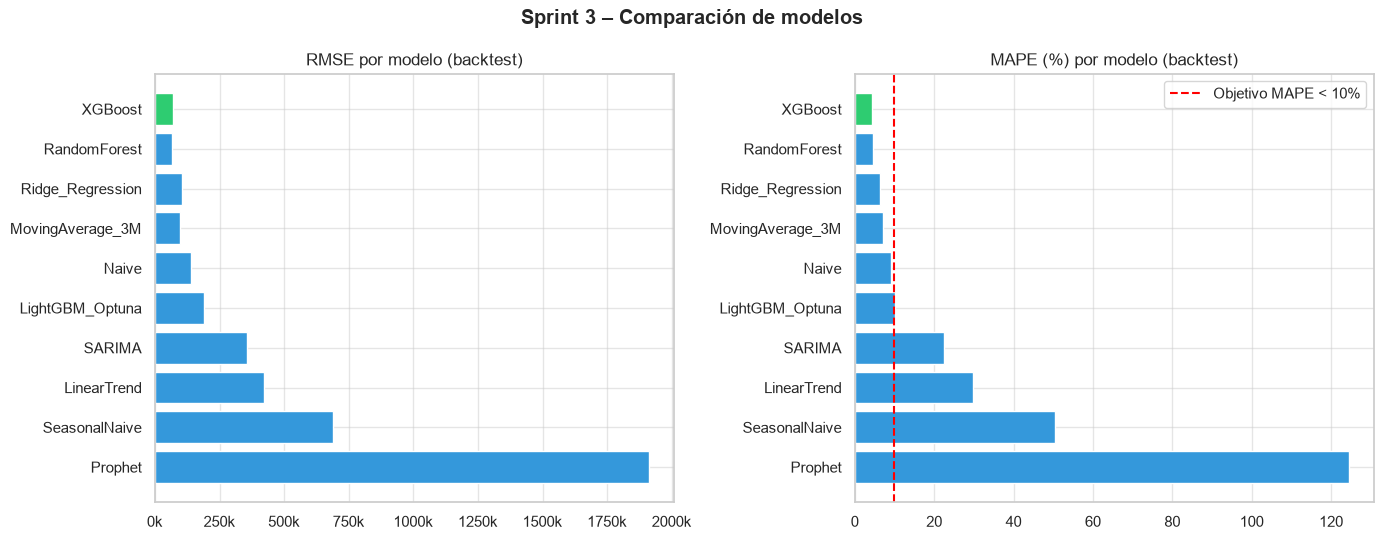

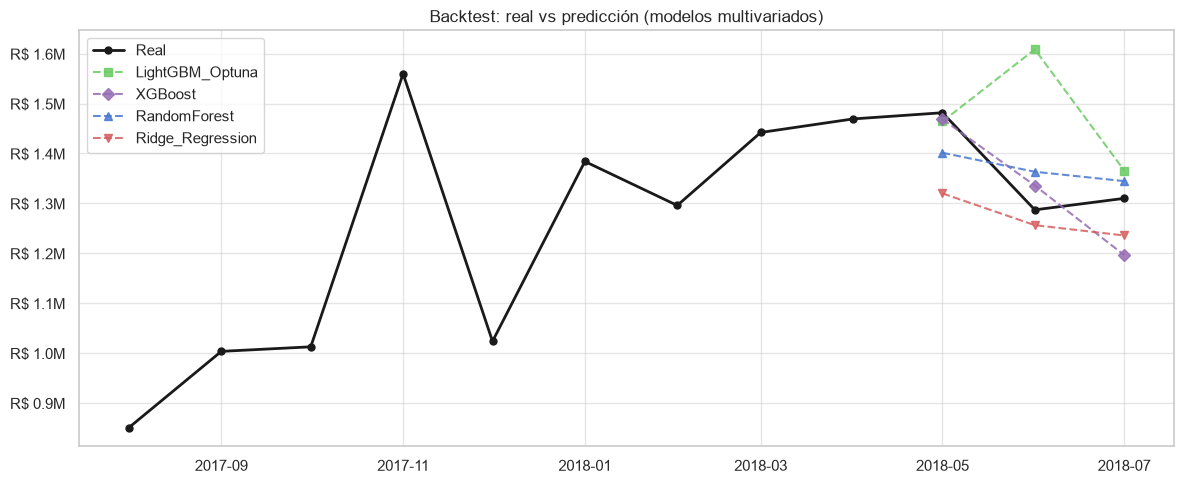

In [109]:
# ── Gráficos de rendimiento (entregable Sprint 3)
os.makedirs('reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in comparison['model']]

axes[0].barh(comparison['model'], comparison['rmse'], color=colors)
axes[0].set_title('RMSE por modelo (backtest)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].invert_yaxis()

axes[1].barh(comparison['model'], comparison['mape'], color=colors)
axes[1].axvline(10, color='red', ls='--', lw=1.5, label='Objetivo MAPE < 10%')
axes[1].set_title('MAPE (%) por modelo (backtest)')
axes[1].invert_yaxis()
axes[1].legend()

plt.suptitle('Sprint 3 – Comparación de modelos', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/sprint3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Real vs predicción en el backtest (modelos multivariados)
fig, ax = plt.subplots(figsize=(12, 5))
hist = all_data.tail(12)
ax.plot(hist['ds'], hist[target], 'k-o', label='Real', lw=2, ms=5)
styles = {'LightGBM_Optuna': 'g--s', 'XGBoost': 'm--D',
          'RandomForest': 'b--^', 'Ridge_Regression': 'r--v'}
for name, style in styles.items():
    ax.plot(test_data['ds'][:n_test], preds[name], style, label=name, alpha=0.85)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Backtest: real vs predicción (modelos multivariados)')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_backtest_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 4 – Modelo final: reentrenamiento con todo el histórico + forecast

El modelo final se reentrena con **todos los meses disponibles** (práctica estándar una vez validado en backtest) y se genera el forecast de los próximos 3 meses con **intervalos de confianza basados en residuos** (`predict_with_intervals`, que reemplaza el supuesto fijo de ±15% usado provisionalmente en el Sprint 2).

2026-06-13 10:16:40.153 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-13 10:16:40.154 | INFO     | src.models.trainer:train_final_model:158 - Modelo final entrenado con mejores hiperparámetros


Entrenando modelo final con todo el histórico…

 FORECAST – próximos 3 meses (IC 95%):
  Aug 2018: R$ 1,305,752.60   [R$ 1,151,797.43 – R$ 1,459,707.78]
  Sep 2018: R$ 1,291,812.23   [R$ 1,017,427.57 – R$ 1,566,196.89]
  Oct 2018: R$ 1,416,835.27   [R$ 1,090,412.70 – R$ 1,743,257.83]


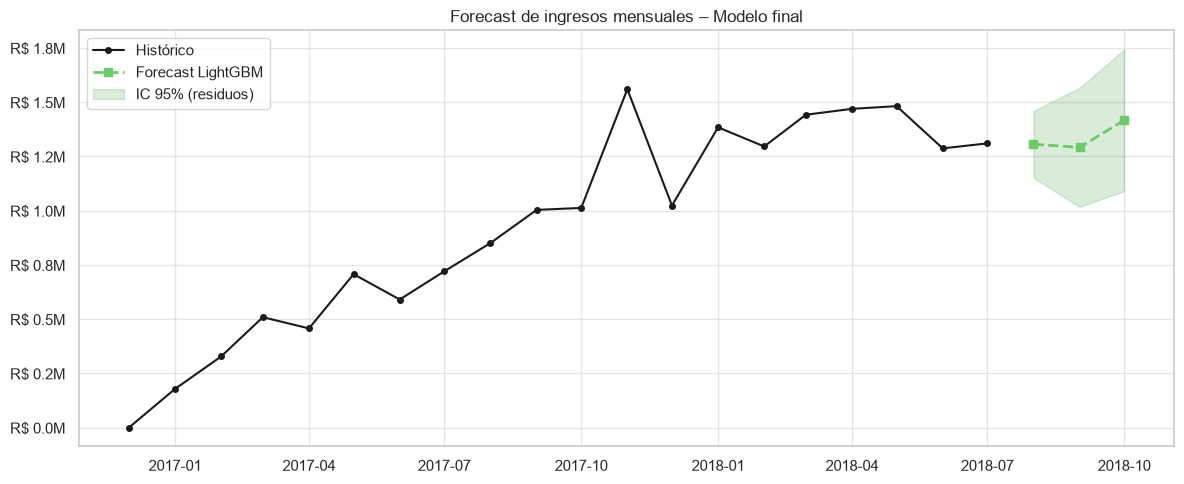

In [110]:
print('Entrenando modelo final con todo el histórico…')
final_forecaster = train_final_model(all_data[selected_features], all_data[target],
                                     best_params, selected_features, horizon=horizon)

# Forecast con IC 95% basado en residuos in-sample (inflados x1.5 por conservadurismo)
forecast_ci = final_forecaster.predict_with_intervals(all_data[selected_features].tail(1))
last_date   = all_data['ds'].max()
forecast_ci['ds'] = [last_date + pd.DateOffset(months=int(h)) for h in forecast_ci['horizon']]

print('\n FORECAST – próximos 3 meses (IC 95%):')
print('='*70)
for _, r in forecast_ci.iterrows():
    print(f"  {r['ds']:%b %Y}: R$ {r['yhat']:>12,.2f}   "
          f"[R$ {r['yhat_lower']:>12,.2f} – R$ {r['yhat_upper']:>12,.2f}]")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_data['ds'], all_data[target], 'k-o', label='Histórico', lw=1.5, ms=4)
ax.plot(forecast_ci['ds'], forecast_ci['yhat'], 'g--s', label='Forecast LightGBM', lw=2)
ax.fill_between(forecast_ci['ds'], forecast_ci['yhat_lower'], forecast_ci['yhat_upper'],
                color='green', alpha=0.15, label='IC 95% (residuos)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Forecast de ingresos mensuales – Modelo final')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

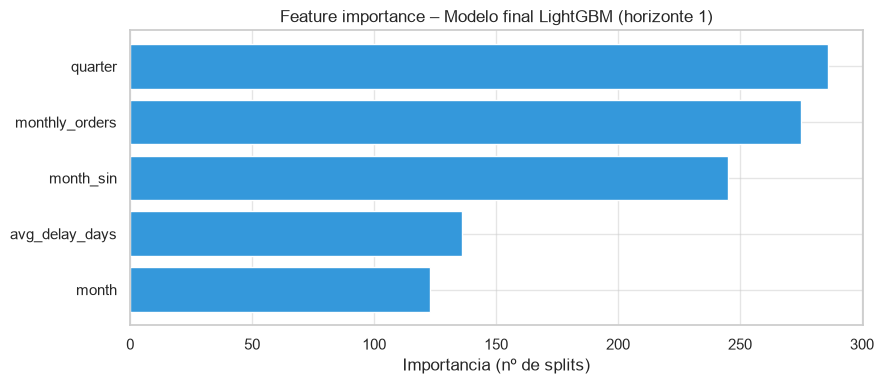

,feature,importance
4,quarter,286
0,monthly_orders,275
2,month_sin,245
1,avg_delay_days,136
3,month,123


In [111]:
# ── Feature importance del modelo final (entregable Sprint 3)
fi = final_forecaster.feature_importance()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi['feature'], fi['importance'], color='#3498db')
ax.invert_yaxis()
ax.set_title('Feature importance – Modelo final LightGBM (horizonte 1)')
ax.set_xlabel('Importancia (nº de splits)')
plt.tight_layout()
plt.savefig('reports/sprint3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
fi

### Paso 4b – Salida de la Selección de Variables

El flujo de ejemplo exige como salida una **tabla por variable** (exportable a CSV) con:

`Nro | Dominio | Variable | flagSelected | importancia_seleccion | importancia_modelo_final`

Adaptación: el *Dominio* se infiere del prefijo de la variable (Calendario, Historia del target, Órdenes, Entregas…), `importancia_seleccion` es el score de información mutua normalizado a 100% entre seleccionadas, e `importancia_modelo_final` es la importancia del LightGBM final normalizada a 100%.

In [112]:
from src.features.selection_table import build_selection_table, export_selection_table

sel_table = build_selection_table(
    all_columns=list(monthly_clean.columns),
    selected_features=selected_features,
    steps_report=selection_result['steps_report'],
    final_importance=final_forecaster.feature_importance(),
    target_col=target,
)
csv_path = export_selection_table(sel_table, 'reports/seleccion_variables.csv')

print(f" Tabla exportada: {csv_path} ({len(sel_table)} variables)\n")
print('Variables SELECCIONADAS (flagSelected = 1):')
print(sel_table[sel_table['flagSelected'] == 1].to_string(index=False))
print('\nResumen por dominio:')
print(sel_table.groupby('Dominio')['flagSelected'].agg(['count', 'sum'])
      .rename(columns={'count': 'total', 'sum': 'seleccionadas'}).to_string())
sel_table.head(15)

2026-06-13 10:16:52.452 | INFO     | src.features.selection_table:build_selection_table:124 - Tabla de selección generada: 44 variables, 5 seleccionadas (importancia_seleccion suma 100.0%)
2026-06-13 10:16:52.460 | INFO     | src.features.selection_table:export_selection_table:135 - Tabla de selección exportada: reports/seleccion_variables.csv


 Tabla exportada: reports/seleccion_variables.csv (44 variables)

Variables SELECCIONADAS (flagSelected = 1):
 Nro                     Dominio       Variable  flagSelected  importancia_seleccion  importancia_modelo_final
   4                     Órdenes monthly_orders             1                  50.87                     25.82
  11                    Entregas avg_delay_days             1                  13.47                     12.77
  39 Calendario / Estacionalidad          month             1                  18.60                     11.55
  40 Calendario / Estacionalidad        quarter             1                   5.73                     26.85
  41 Calendario / Estacionalidad      month_sin             1                  11.34                     23.00

Resumen por dominio:
                             total  seleccionadas
Dominio                                          
Calendario / Estacionalidad      8              3
Clientes                         1              0
Di

,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final
0,1,Calendario / Estacionalidad,year_month,0,0.00,0.00
1,2,Target,monthly_revenue,0,0.00,0.00
2,3,Calendario / Estacionalidad,ds,0,0.00,0.00
3,4,Órdenes,monthly_orders,1,50.87,25.82
4,5,Clientes,monthly_customers,0,0.00,0.00
5,6,Órdenes,monthly_items,0,0.00,0.00
6,7,Ticket / Precio,avg_ticket,0,0.00,0.00
7,8,Ticket / Precio,median_ticket,0,0.00,0.00
8,9,Satisfacción,avg_review_score,0,0.00,0.00
9,10,Entregas,avg_delivery_days,0,0.00,0.00


## Paso 5 – Exportación del modelo final (.pkl)

Se exportan dos artefactos:

- `lgbm_forecaster.pkl` y `cleaning_pipeline.pkl`: artefactos **operativos** que consume `PredictPipeline` en la ejecución mensual.
- `final_model.pkl`: **bundle con metadata** de trazabilidad (`final_model['metadata']`, el equivalente práctico del `final_model.__dict__` del flujo de ejemplo) — features, hiperparámetros, métricas del backtest, **gap de sobreajuste**, costo de selección, rango de entrenamiento y **versiones exactas de librerías**.

In [113]:
import platform, json
from datetime import datetime
from src.utils.helpers import save_model

# 1) Artefactos operativos (compatibles con PredictPipeline)
save_model(final_forecaster, 'lgbm_forecaster')
save_model(cleaning_pipeline, 'cleaning_pipeline')

# 2) Bundle final con metadata de trazabilidad
m   = comparison[comparison['model'] == 'LightGBM_Optuna'].iloc[0]
g   = gap_df[gap_df['model'] == 'LightGBM_Optuna'].iloc[0]
challenger = comparison[comparison['model'].isin(['RandomForest', 'XGBoost', 'MovingAverage_3M'])]
metadata = {
    'model_type':        'LightGBMForecaster (direct multi-step, 3 horizontes)',
    'trained_at':        datetime.now().isoformat(timespec='seconds'),
    'training_range':    f"{all_data['ds'].min():%Y-%m} → {all_data['ds'].max():%Y-%m}",
    'n_train_months':    int(len(all_data)),
    'selected_features': selected_features,
    'best_params':       best_params,
    'metrics_backtest':  {k: float(m[k]) for k in ['rmse', 'mae', 'mape', 'smape']},
    'overfit_gap': {
        'rmse_train':     float(g['rmse_train']),
        'rmse_backtest':  float(g['rmse_backtest']),
        'gap_rmse_ratio': float(g['gap_rmse_ratio']),
    },
    'challengers_backtest': {
        r['model']: round(float(r['mape']), 2) for _, r in challenger.iterrows()
    },
    'selection_cost':    cost_df.to_dict('records'),
    'versions': {
        'python':       platform.python_version(),
        'scikit-learn': sklearn.__version__,
        'lightgbm':     lightgbm.__version__,
        'xgboost':      xgboost.__version__,
        'optuna':       optuna.__version__,
        'pandas':       pd.__version__,
        'numpy':        np.__version__,
    },
}
save_model({'forecaster': final_forecaster, 'metadata': metadata}, 'final_model')

print('\n Artefactos guardados en data/models/:')
print('   - lgbm_forecaster.pkl   (operativo – PredictPipeline)')
print('   - cleaning_pipeline.pkl (operativo – PredictPipeline)')
print('   - final_model.pkl       (modelo + metadata ≈ final_model.__dict__)')
print('\n Metadata del modelo final:')
print(json.dumps(metadata, indent=2, ensure_ascii=False, default=str))

2026-06-13 10:16:59.344 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\lgbm_forecaster.pkl
2026-06-13 10:16:59.369 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\cleaning_pipeline.pkl
2026-06-13 10:16:59.429 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\final_model.pkl



 Artefactos guardados en data/models/:
   - lgbm_forecaster.pkl   (operativo – PredictPipeline)
   - cleaning_pipeline.pkl (operativo – PredictPipeline)
   - final_model.pkl       (modelo + metadata ≈ final_model.__dict__)

 Metadata del modelo final:
{
  "model_type": "LightGBMForecaster (direct multi-step, 3 horizontes)",
  "trained_at": "2026-06-13T10:16:59",
  "training_range": "2016-12 → 2018-07",
  "n_train_months": 20,
  "selected_features": [
    "monthly_orders",
    "avg_delay_days",
    "month_sin",
    "month",
    "quarter"
  ],
  "best_params": {
    "n_estimators": 638,
    "learning_rate": 0.0835361075531176,
    "num_leaves": 19,
    "max_depth": 4,
    "min_child_samples": 6,
    "subsample": 0.7301321323053057,
    "colsample_bytree": 0.7554709158757928,
    "reg_alpha": 0.2713490317738959,
    "reg_lambda": 0.8287375091519293
  },
  "metrics_backtest": {
    "rmse": 188709.76062561065,
    "mae": 131616.38347241064,
    "mape": 10.142280593949494,
    "smape": 9.18

## Justificación del modelo elegido

**Lectura honesta de los resultados (backtest de 3 meses):**

- **XGBoost** logra el mejor MAPE (~4.5%) pero con un gap train→backtest extremo (su error crece ~180x al salir del train: con 17 meses memoriza el train casi a la perfección). Según el criterio del propio flujo de ejemplo — *reducir la distancia train vs backtest* — queda **descartado** pese a su MAPE: no hay evidencia de que generalice.
- **Random Forest** combina el segundo mejor MAPE (~4.7%) con el mejor gap (≈1): el candidato con mejor equilibrio precisión–generalización en esta ventana.
- **LightGBM (Optuna)** queda en ~10.1% con gap moderado (≈1.8). **Ridge** ~6.3% (gap ≈1.5). Los baselines simples (MA-3M ~7.1%) siguen siendo competitivos, algo esperable con ~20 meses de historia.
- Prophet y SARIMA colapsan (>20% MAPE): una serie tan corta no alcanza para estimar bien estacionalidad anual univariada.

**Decisión: LightGBM se mantiene como champion operativo de esta iteración; Random Forest queda como challenger principal.** Justificación:

1. **n=3 no es concluyente:** con solo 3 puntos de backtest, la diferencia RF vs LightGBM puede ser azar muestral. Cambiar el modelo de producción por 3 observaciones sería sobre-reaccionar al ruido (el mismo error que el gap intenta evitar).
2. **Requisitos operativos del proyecto:** LightGBM es el único candidato con actualización incremental (`update()` con `init_model`, requisito del Sprint 2), espacio de búsqueda Optuna ya integrado e intervalos de predicción por residuos. RF/XGBoost requieren reentrenar desde cero cada mes.
3. **Regla de promoción explícita (champion–challenger):** cada mes se compara el MAPE realizado de LightGBM vs Random Forest (challenger multivariado) y MA-3M (challenger estadístico), registrados en `metadata['challengers_backtest']`. **Si un challenger gana 2 meses consecutivos con datos reales, se promueve a champion.** Así la decisión se corrige sola con evidencia, no con ruido.

**Nota sobre la evaluación:** a diferencia de la versión preliminar del Sprint 2 (que evaluaba usando features del propio período de test), aquí la predicción multi-step se hace **solo con información disponible al final de train** — sin fuga de información. Estos son los números realistas de producción.

## Pipeline de retraining mensual (documentación operativa)

Cada mes, al llegar los nuevos CSVs de Olist:

```text
1. Colocar los CSVs actualizados en data/raw/
2. Reentrenamiento completo (recomendado 1 vez por trimestre):
       from src.pipeline.train_pipeline import TrainPipeline
       TrainPipeline().run(tune=True)          # re-optimiza con Optuna
3. Actualización incremental (mensual, barata):
       pipe = TrainPipeline(); pipe.run(tune=False)
       pipe.step_incremental_update(new_month_df)   # warm-start +20 árboles
4. Predicción del mes siguiente:
       from src.pipeline.predict_pipeline import PredictPipeline
       PredictPipeline().run()                 # carga lgbm_forecaster.pkl + cleaning_pipeline.pkl
5. Monitoreo champion-challenger:
       - comparar MAPE realizado de LightGBM vs RandomForest y MA-3M
       - monitorear gap train→backtest del retraining (metadata['overfit_gap'])
       - challenger gana 2 meses seguidos  → promover a champion
       - MAPE > 10% durante 2 meses seguidos → reentrenamiento completo con tuning
```

## Conclusiones del Sprint 3

- Se compararon **9 modelos** (4 baselines + RF + Ridge + XGBoost + LightGBM + Prophet + SARIMA) bajo el mismo protocolo de backtest sin fuga de información, cubriendo los candidatos del flujo de ejemplo (árboles, regresión, XGBoost).
- La **salida de la selección de variables** queda trazable variable a variable (`reports/seleccion_variables.csv` con flagSelected + importancias) y se cuantificó el **costo de la selección** (equivalente al "60→30: Gini 50→47").
- El **gap train→backtest** operacionaliza el control de sobreajuste del flujo de ejemplo: descartó a XGBoost (mejor MAPE pero gap ~180x) y reveló a Random Forest como challenger serio — exactamente el tipo de decisión que esta métrica existe para informar.
- La hiperparametrización con **Optuna + CV temporal** (30 trials) define el modelo final de forma reproducible.
- El modelo final se exporta como **`final_model.pkl`** con metadata completa (≈ `final_model.__dict__`), incluyendo métricas de challengers para el monitoreo mensual, y queda listo para `PredictPipeline`.
- Los intervalos del forecast se basan en **residuos del modelo** (IC 95%), reemplazando el supuesto fijo ±15%.